# Econ 524 — Lab: Introduction to Deep Learning
### Instructor run sheet — 50 minutes

**Covers Lecture 2, slides 38–52**: architectures of neural networks through
*Training NNs: Basic Idea*. Gradient descent, backpropagation, SGD and dropout are the
next lecture; this session builds the intuition they will formalize.

| Time | § | Topic | Compute |
|------|---|-------|---------|
| 0–3 | 0 | Setup and framing | 1 s |
| 3–7 | 1 | Why neural networks? *(talk only)* | — |
| 7–14 | 2 | One neuron, geometrically | <1 s |
| 14–18 | 3 | Wiring neurons into a network | <1 s |
| 18–30 | 4 | **Approximating $\sin$** — the centrepiece | 6 s |
| 30–42 | 5 | **Training: why it is hard** | 2 s |
| 42–48 | 6 | Application: expected goals | 1 s |
| 48–50 | 7 | Bridge to MNIST, and close | <1 s |
| — | 8 | MNIST, `scikit-learn` and PyTorch *(self-study)* | see note |
| — | A–E | Appendices *(self-study)* | 60 s |

Total live compute on the core path is **about 11 seconds**. The session is paced by
talking, not by waiting — which is the point of the design.

---

### Before class — two things

**1. Run the pre-flight cell below.** It warms the imports and, more importantly,
downloads the MNIST data to a local cache. That download is ~55 MB and is **the single
biggest risk to this session**: thirty students hitting OpenML simultaneously on
classroom wifi will not go well. Cached, it is instant.

**2. Decide how far you will get.** §8 (MNIST) will not fit inside 50 minutes if the
earlier sections breathe properly. Treat it as a demo you *show* in the last two minutes
or assign as reading. The PyTorch/`skorch` half runs 20 epochs on CPU — budget a minute
or two of dead air if you do run it live.

### If you are running behind

Cut in this order. Each is marked `CUT FIRST` in place:

1. **§4, the trained-network graph** — pretty, but §3 already made the point.
2. **§4, the weight table** — the three-panel plot right after it says the same thing.
3. **§5, the convexity-violation counter** — state the result, show the contour plot.

Do **not** cut the 30-random-starts cell at the end of §5. It is the most useful thing in
the notebook for their own empirical work.

### What is deliberately not here

| | Where it went | Why |
|---|---|---|
| Approximating $\exp\{4z\}$ (slide 46) | Appendix A | Duplicates the $\sin$ lesson |
| Depth vs. width (slides 47–48) | Appendix B | Needs 10 min to do honestly |
| Random features | Appendix C | Lovely, not examinable |
| Finance: option-pricing surface | Appendix D | Best application, no room |
| Health: clinical risk | Appendix E | Pairs with Assignment 2 |

Appendices are written to be read alone, without the instructor. Point students at
**D** especially — it is where deep learning most often bites applied economists.


In [41]:
# ============================================================
# PRE-FLIGHT — run this BEFORE class, not during it.
# Caches MNIST locally so section 8 does not stall on a 55 MB download.
# ============================================================
import time, warnings
warnings.simplefilter("ignore")

t0 = time.time()
from sklearn.datasets import fetch_openml

try:
    _ = fetch_openml("mnist_784", as_frame=False, cache=True)
    print(f"MNIST cached in {time.time() - t0:.1f}s  -> section 8 will load instantly.")
except Exception as e:
    print("MNIST download FAILED:", type(e).__name__, e)
    print("\nFall back to one of these before class:")
    print("  * run this cell again on a different network")
    print("  * use sklearn.datasets.load_digits() (8x8 images, ships with sklearn)")
    print("  * skip section 8 entirely and assign it as reading")

MNIST cached in 1.2s  -> section 8 will load instantly.


`⏱ 0–3 min`  ·  **CORE — setup & framing**

# Introduction to Deep Learning

**Econ 524 · Big Data Econometrics · Emory University**

Lecture 2 splits nonlinear machine learning in two. We did the left branch last time.

```
Nonlinear Machine Learning
├── Tree-Based Methods          <- previous lab
│   ├── CART
│   ├── Bagging / Random Forests
│   └── Boosted Trees
└── Neural Networks             <- TODAY
    ├── Single Layer Neural Networks
    └── Multilayer Neural Networks (Deep Learning)
```

Today covers **slides 38-52**, stopping exactly where the lecture stops: at
*Training NNs: Basic Idea*. Gradient descent and backpropagation are next time.

**How this notebook works.** Every section runs the same arc: *a picture, then the
mathematics behind the picture, then a check that the mathematics is true.* Nothing is
asserted here that is not verified in code somewhere below — including the places where
the result is inconvenient.

Sections 1-7 are the 50 minutes. Section 8 and Appendices A-E are yours to read
afterwards, and are written to be read alone.


In [42]:
# ============================================================
# Setup — run this first
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "font.size": 10})

SEED = 524
rng = np.random.default_rng(SEED)

relu    = lambda u: np.maximum(u, 0.0)
sigmoid = lambda u: 1.0 / (1.0 + np.exp(-u))
step    = lambda u: (u > 0).astype(float)

print("Setup complete.")

Setup complete.


`⏱ 3–7 min`  ·  **CORE — talk only, nothing to run**

---
# 1. Why neural networks at all?

Lecture 2 opens with the object we actually want:

$$
E[Y \mid Z] \;=\; \arg\min_{f}\; E\big[(Y - f(Z))^2\big]
$$

The conditional expectation function (CEF) is the **best possible predictor** of $Y$
given $Z$ — best among *all* functions, not just linear ones. Everything in Lecture 1
restricted $f$ to the linear class $\hat\alpha_n + z^\top\hat\beta_n$, which delivers the
best **linear** predictor (BLP). If the CEF is nonlinear, the BLP can be far from it.

So we need a flexible family $f(z,\theta)$, with $\theta$ finite-dimensional, that can get
close to any reasonable CEF.

### The one idea you should carry out of this lab

You already know one way to approximate a nonlinear function: **series regression**.
Pick basis functions and run OLS on them.

$$
f(z) \;\approx\; \beta_0 + \sum_{j=1}^{k}\beta_j \, \underbrace{\phi_j(z)}_{\text{you choose these}}
$$

Polynomials: $\phi_j(z) = z^j$. Splines: fixed knots you place by hand. In every case
**the basis is chosen before you see the data**, and only the coefficients $\beta$ are
estimated.

A single-layer neural network has *exactly the same shape*:

$$
f(z) \;=\; \beta_0 + \sum_{j=1}^{k}\beta_j\,\underbrace{\sigma(\omega_{j0} + \omega_{j1}z_1 + \dots + \omega_{jp}z_p)}_{\text{the network chooses these}}
$$

with one difference, and it is the whole difference:

> **A neural network is a linear regression on basis functions that it learns from the data.**
> The $\beta_j$ are regression coefficients on the basis; the $\omega_{j\ell}$ *are the basis*.

Series regression estimates $\beta$ with the basis fixed — a **convex, linear** problem.
A network estimates $\beta$ *and* $\omega$ jointly — a **nonconvex** problem. That single
change buys the adaptivity that makes deep learning work in high dimensions, and it
is also the source of every difficulty in §6. Keep this trade in mind; it explains
the rest of the notebook.

*(This framing — "adaptive basis" vs. "fixed basis" — is the standard way the
approximation-theory literature reads the universal approximation theorem. It is not
stated in these words on the slides, but it is the content of slides 43–46.)*


`⏱ 7–14 min`  ·  **CORE**

---
# 2. One neuron, geometrically

A neuron does two things, in order:

1. **An affine map** — a linear index, exactly like the inside of a logit:
   $\;u = \omega_{j0} + \omega_{j1}z_1 + \dots + \omega_{jp}z_p$
2. **A nonlinear squash** — the *activation function* $\sigma : \mathbb{R}\to\mathbb{R}$

The result $a_j = \sigma(\omega_{j0} + \omega_{j1}z_1 + \dots + \omega_{jp}z_p)$ is the
**activation**. The $\omega_{j\ell}$ with $\ell > 0$ are **weights**; $\omega_{j0}$ is the
**bias**.

Why the nonlinearity is non-negotiable: if $\sigma$ were the identity, then a composition
of affine maps is again affine, and a hundred-layer network would collapse to a single
linear regression. **The activation is the only thing standing between a deep network and
OLS.**

### The three activations from slide 44

| | $\sigma(u)$ | Status |
|---|---|---|
| **Perceptron** (Heaviside) | $\mathbf{1}\{u>0\}$ | Historical. Derivative is 0 almost everywhere — nothing to optimize with. |
| **Sigmoid** | $e^u/(1+e^u)$ | Popular initially; suffers the *vanishing gradient* problem. |
| **ReLU** | $\max\{u,0\}$ | The modern default. |

Look at the slopes in the plot below and the vanishing-gradient story becomes obvious.


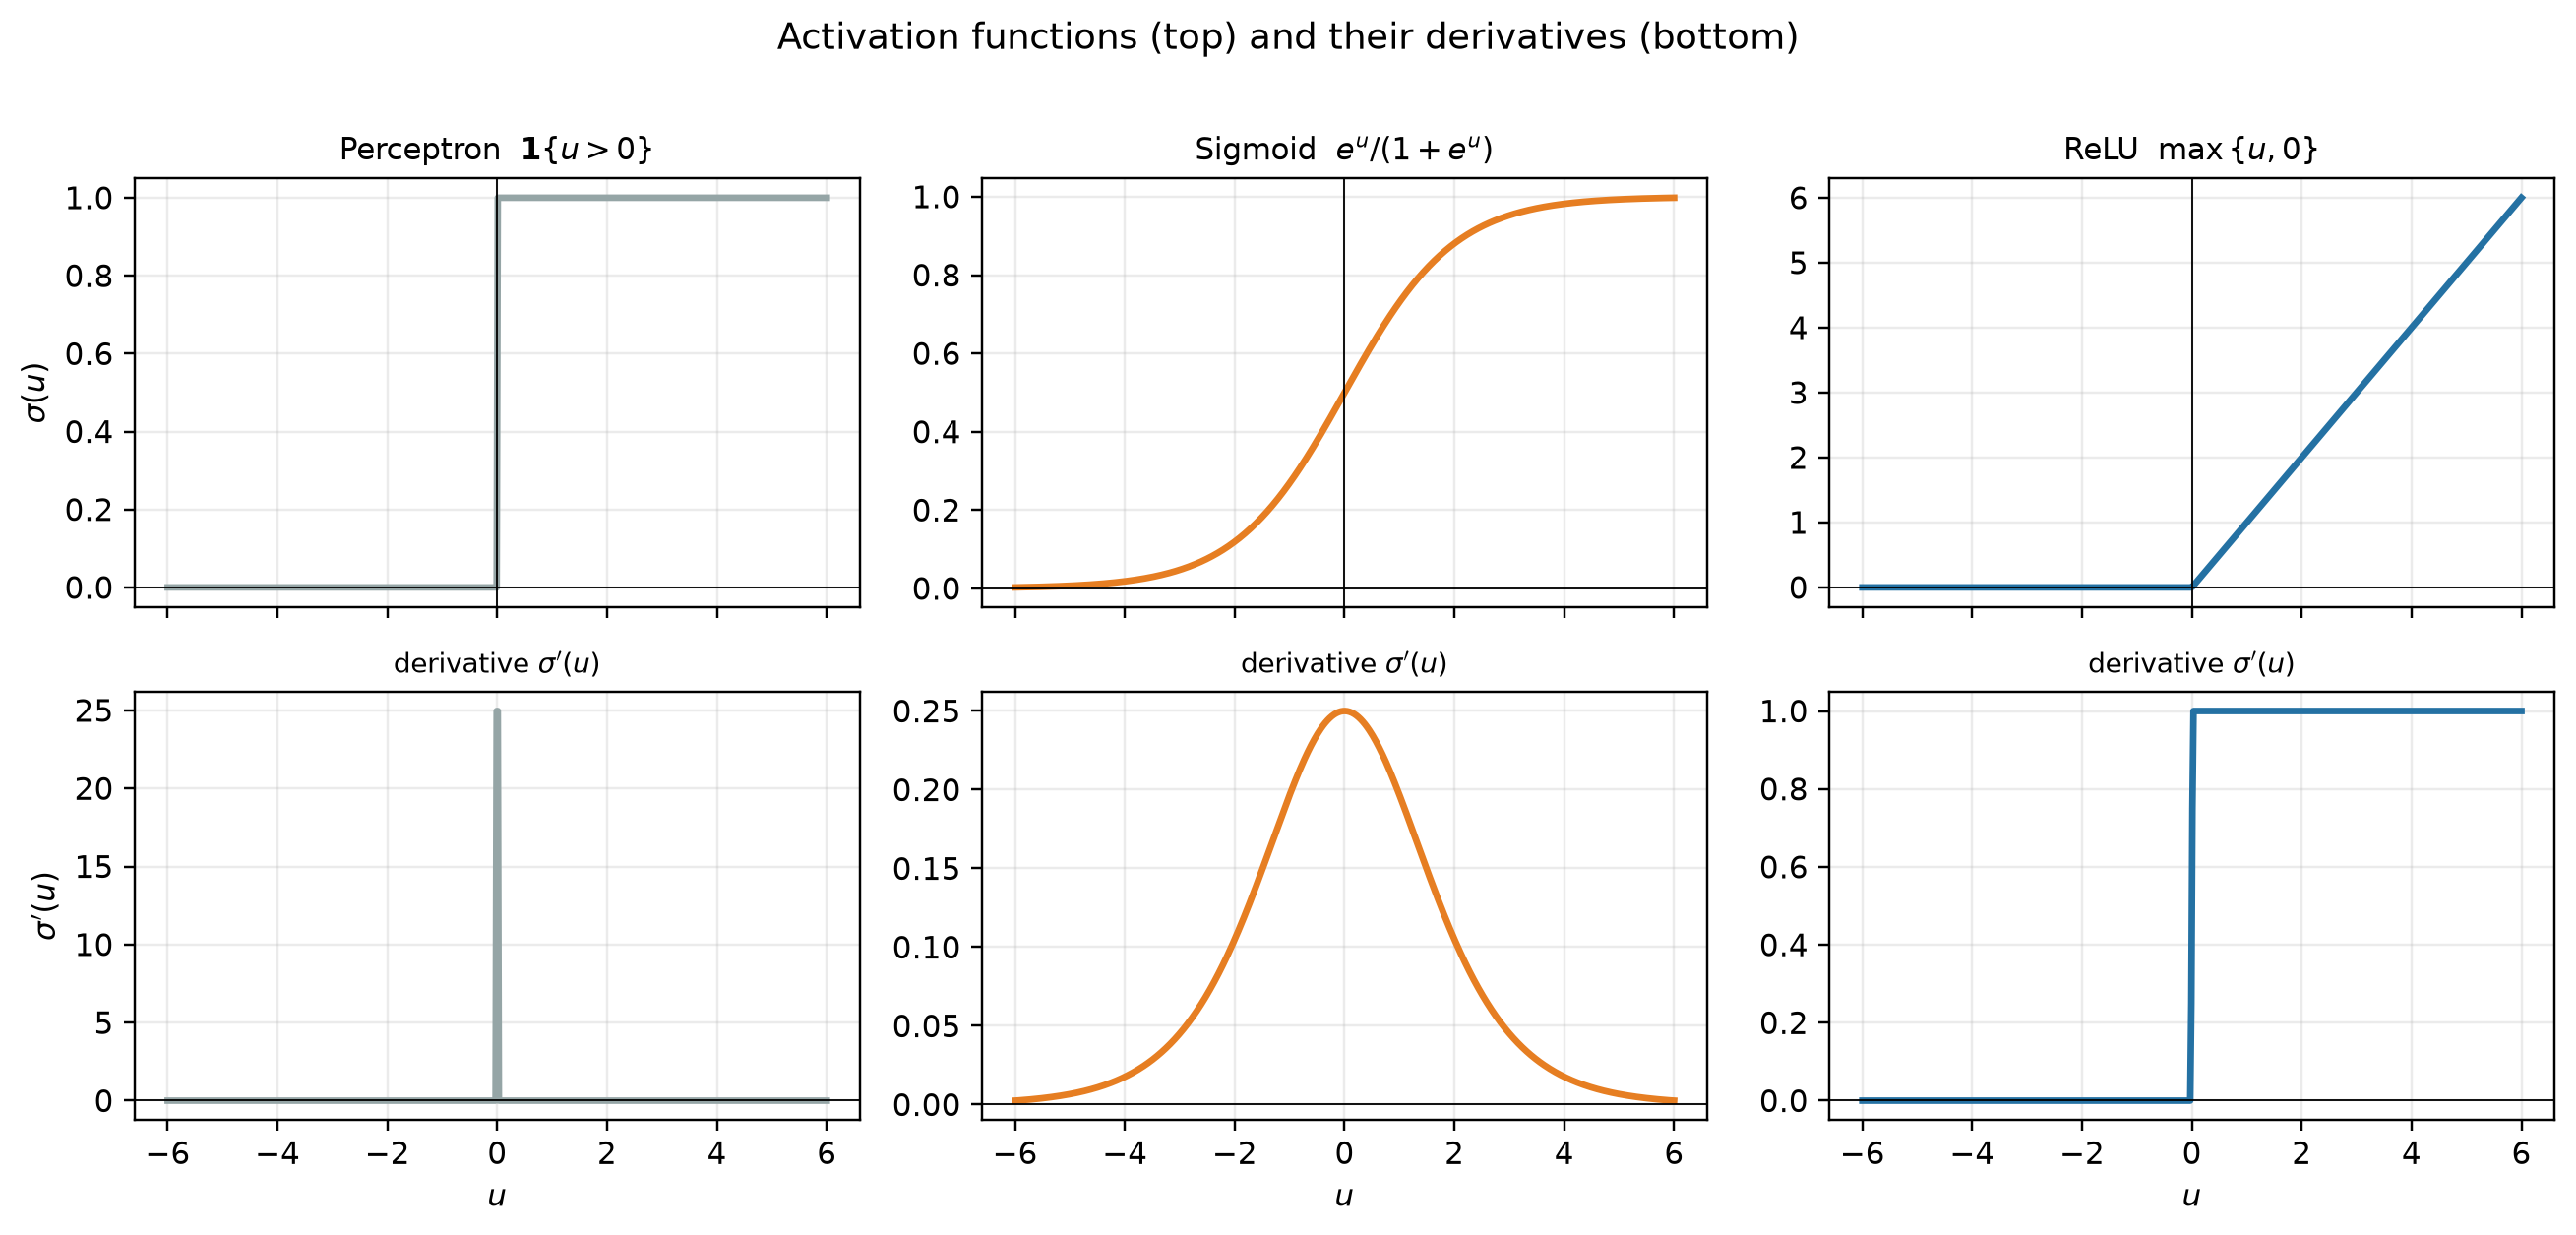

Max sigmoid derivative : 0.25
Sigmoid derivative at |u|=5 : 0.006648


In [43]:
u = np.linspace(-6, 6, 600)
acts = [(step, "Perceptron  $\\mathbf{1}\\{u>0\\}$", "#95a5a6"),
        (sigmoid, "Sigmoid  $e^u/(1+e^u)$", "#e67e22"),
        (relu, "ReLU  $\\max\\{u,0\\}$", "#2471a3")]

fig, ax = plt.subplots(2, 3, figsize=(12, 5.6), sharex=True)
for j, (f, nm, c) in enumerate(acts):
    ax[0, j].plot(u, f(u), lw=2.2, color=c)
    ax[0, j].set_title(nm, fontsize=10)
    ax[0, j].axhline(0, lw=.6, c="k"); ax[0, j].axvline(0, lw=.6, c="k")
    # numerical derivative
    d = np.gradient(f(u), u)
    ax[1, j].plot(u, d, lw=2.2, color=c)
    ax[1, j].set_title("derivative $\\sigma'(u)$", fontsize=9)
    ax[1, j].axhline(0, lw=.6, c="k")
    ax[1, j].set_xlabel("$u$")
ax[0, 0].set_ylabel("$\\sigma(u)$"); ax[1, 0].set_ylabel("$\\sigma'(u)$")
plt.suptitle("Activation functions (top) and their derivatives (bottom)", y=1.01)
plt.tight_layout(); plt.show()

print("Max sigmoid derivative :", round(float(np.max(np.gradient(sigmoid(u), u))), 4))
print("Sigmoid derivative at |u|=5 :", round(float(sigmoid(5)*(1-sigmoid(5))), 6))

**Read the bottom row.** The sigmoid's derivative peaks at $0.25$ and collapses toward
zero as $|u|$ grows. In a network with $L$ layers, the chain rule multiplies $L$ of these
numbers together: $0.25^{10} \approx 10^{-6}$. The learning signal reaching the early
layers is numerically dead — that is the **vanishing gradient problem**, and it is why
the field moved to ReLU, whose derivative is exactly $1$ on the whole active half-line.

### The geometry of a single ReLU neuron

Take $p=1$ so we can draw it. A neuron computes $a = \max\{\omega_0 + \omega_1 z,\;0\}$.
This is a **hinge**: flat at zero, then a straight ray. Two facts, both of which you can
read straight off the algebra:

$$
\underbrace{z^{\star} = -\frac{\omega_0}{\omega_1}}_{\textbf{where the kink sits}},
\qquad
\underbrace{\text{slope} = \omega_1 \text{ on the active side}}_{\textbf{how steep the ray is}}
$$

So the **bias places the kink** and the **weight sets the slope and orientation**. This is
the entire vocabulary of a ReLU network: every neuron contributes one kink at a location
it chooses, with a slope it chooses. Let's verify both claims numerically rather than
take them on faith.


    w0     w1 |  kink -w0/w1  kink (numeric)    slope
--------------------------------------------------------
   1.0    2.0 |      -0.5000         -0.5000      2.0
  -1.5    3.0 |       0.5000          0.5000      3.0
   0.5   -1.0 |       0.5000          0.5000     -1.0
  -2.0    1.0 |       2.0000          2.0000      1.0


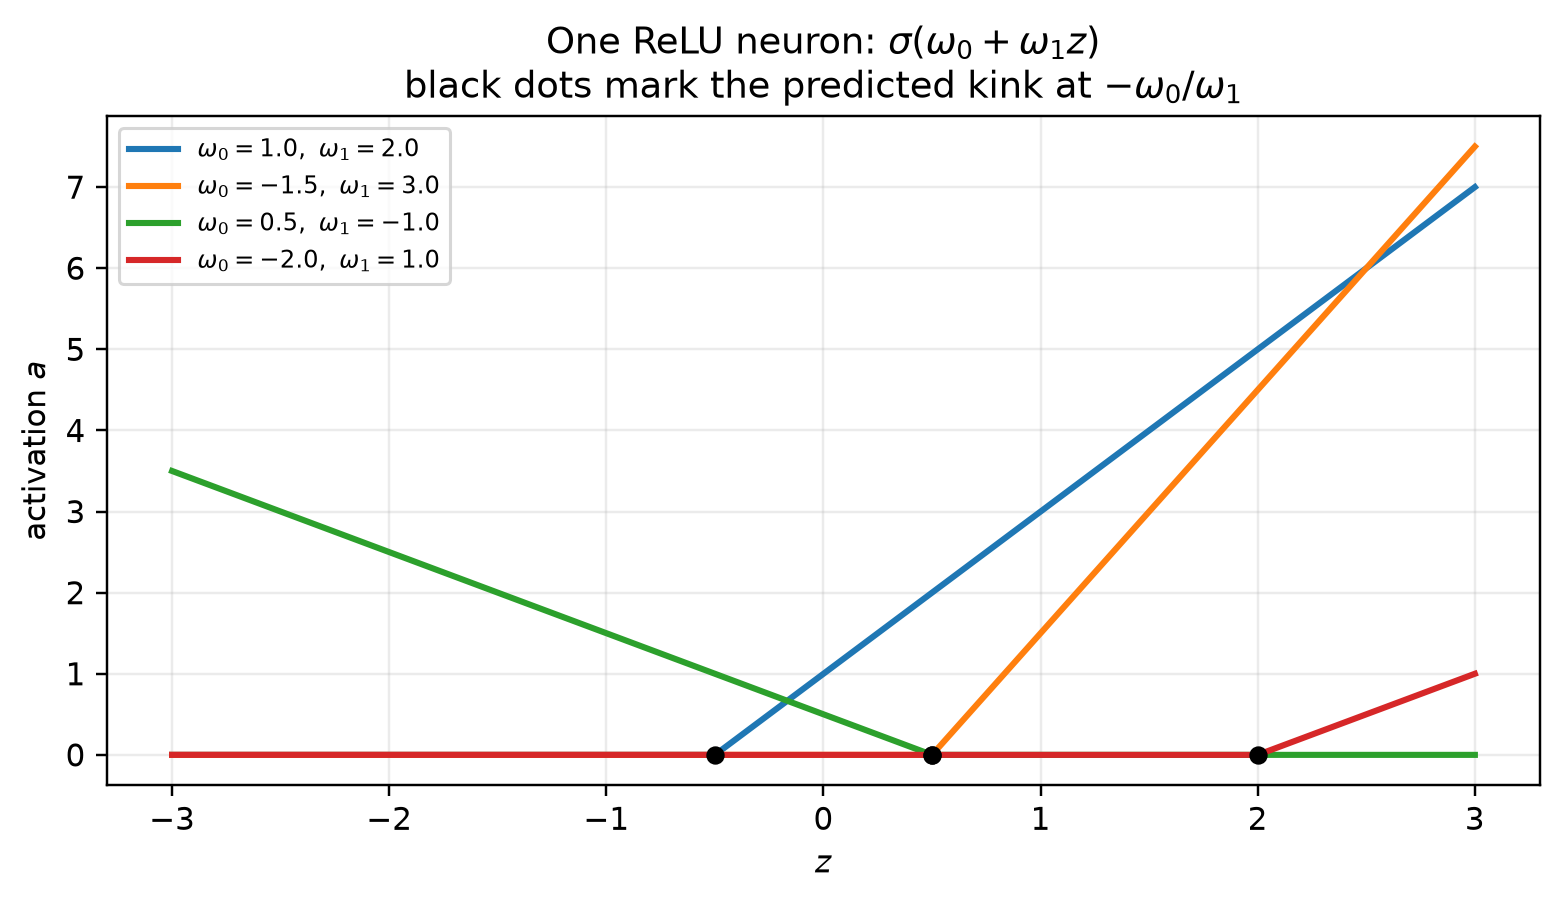

In [44]:
z = np.linspace(-3, 3, 1201)
params = [(1.0, 2.0), (-1.5, 3.0), (0.5, -1.0), (-2.0, 1.0)]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
print(f"{'w0':>6} {'w1':>6} | {'kink -w0/w1':>12} {'kink (numeric)':>15} {'slope':>8}")
print("-" * 56)
for w0, w1 in params:
    a = relu(w0 + w1 * z)
    kink_num = z[1:-1][np.argmax(np.abs(np.diff(a, 2)))]
    ax.plot(z, a, lw=2, label=f"$\\omega_0={w0},\\ \\omega_1={w1}$")
    ax.plot(-w0 / w1, 0, "ko", ms=5, zorder=5)
    print(f"{w0:>6} {w1:>6} | {-w0/w1:>12.4f} {kink_num:>15.4f} {w1:>8.1f}")

ax.set_title("One ReLU neuron: $\\sigma(\\omega_0 + \\omega_1 z)$\n"
             "black dots mark the predicted kink at $-\\omega_0/\\omega_1$")
ax.set_xlabel("$z$"); ax.set_ylabel("activation $a$"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The analytic kink location and the numerically detected one agree to the resolution of
the grid. Note the third row: when $\omega_1 < 0$ the hinge flips — it is *active to the
left*. So the sign of the weight chooses which side of the kink the neuron responds to.


`⏱ 14–18 min`  ·  **CORE**

---
# 3. Wiring neurons into a network

### Shallow neural network (slide 43)

$$
f(z) \;=\; \beta_0 + \sum_{j=1}^{k} \beta_j\,\sigma(\omega_{j0} + \omega_{j1}z_1 + \dots + \omega_{jp}z_p)
$$

One hidden layer, $k$ units. Each unit produces one activation $a_j$; the output layer
takes a plain **linear combination** of them. Note that last step carefully: *the output
layer is a linear regression on the activations.* That is the adaptive-basis idea from §1,
written out.

### Multilayer perceptron (slide 49)

Stack hidden layers and feed each one the previous one's activations:

$$
\begin{aligned}
a_{1j} &= \sigma(\omega_{1j0} + \omega_{1j,1}z_1 + \dots + \omega_{1j,p}z_p) \\[2pt]
a_{lj} &= \sigma(\omega_{lj0} + \omega_{lj,1}a_{l-1,1} + \dots + \omega_{lj,k_{l-1}}a_{l-1,k_{l-1}}) \\[2pt]
f(z)   &= \beta_0 + \sum_{j=1}^{k_L}\beta_{L}a_{Lj}
\end{aligned}
$$

Three structural facts: each layer is **fully connected** to the next; layers need not
have equal width; and information flows **forward only, with no loops** — this is what
*feedforward* means (slide 41).

The function below draws these architectures. We will reuse it later to look at a
network that has actually been **trained**, with edge colour and thickness showing the
learned weights.


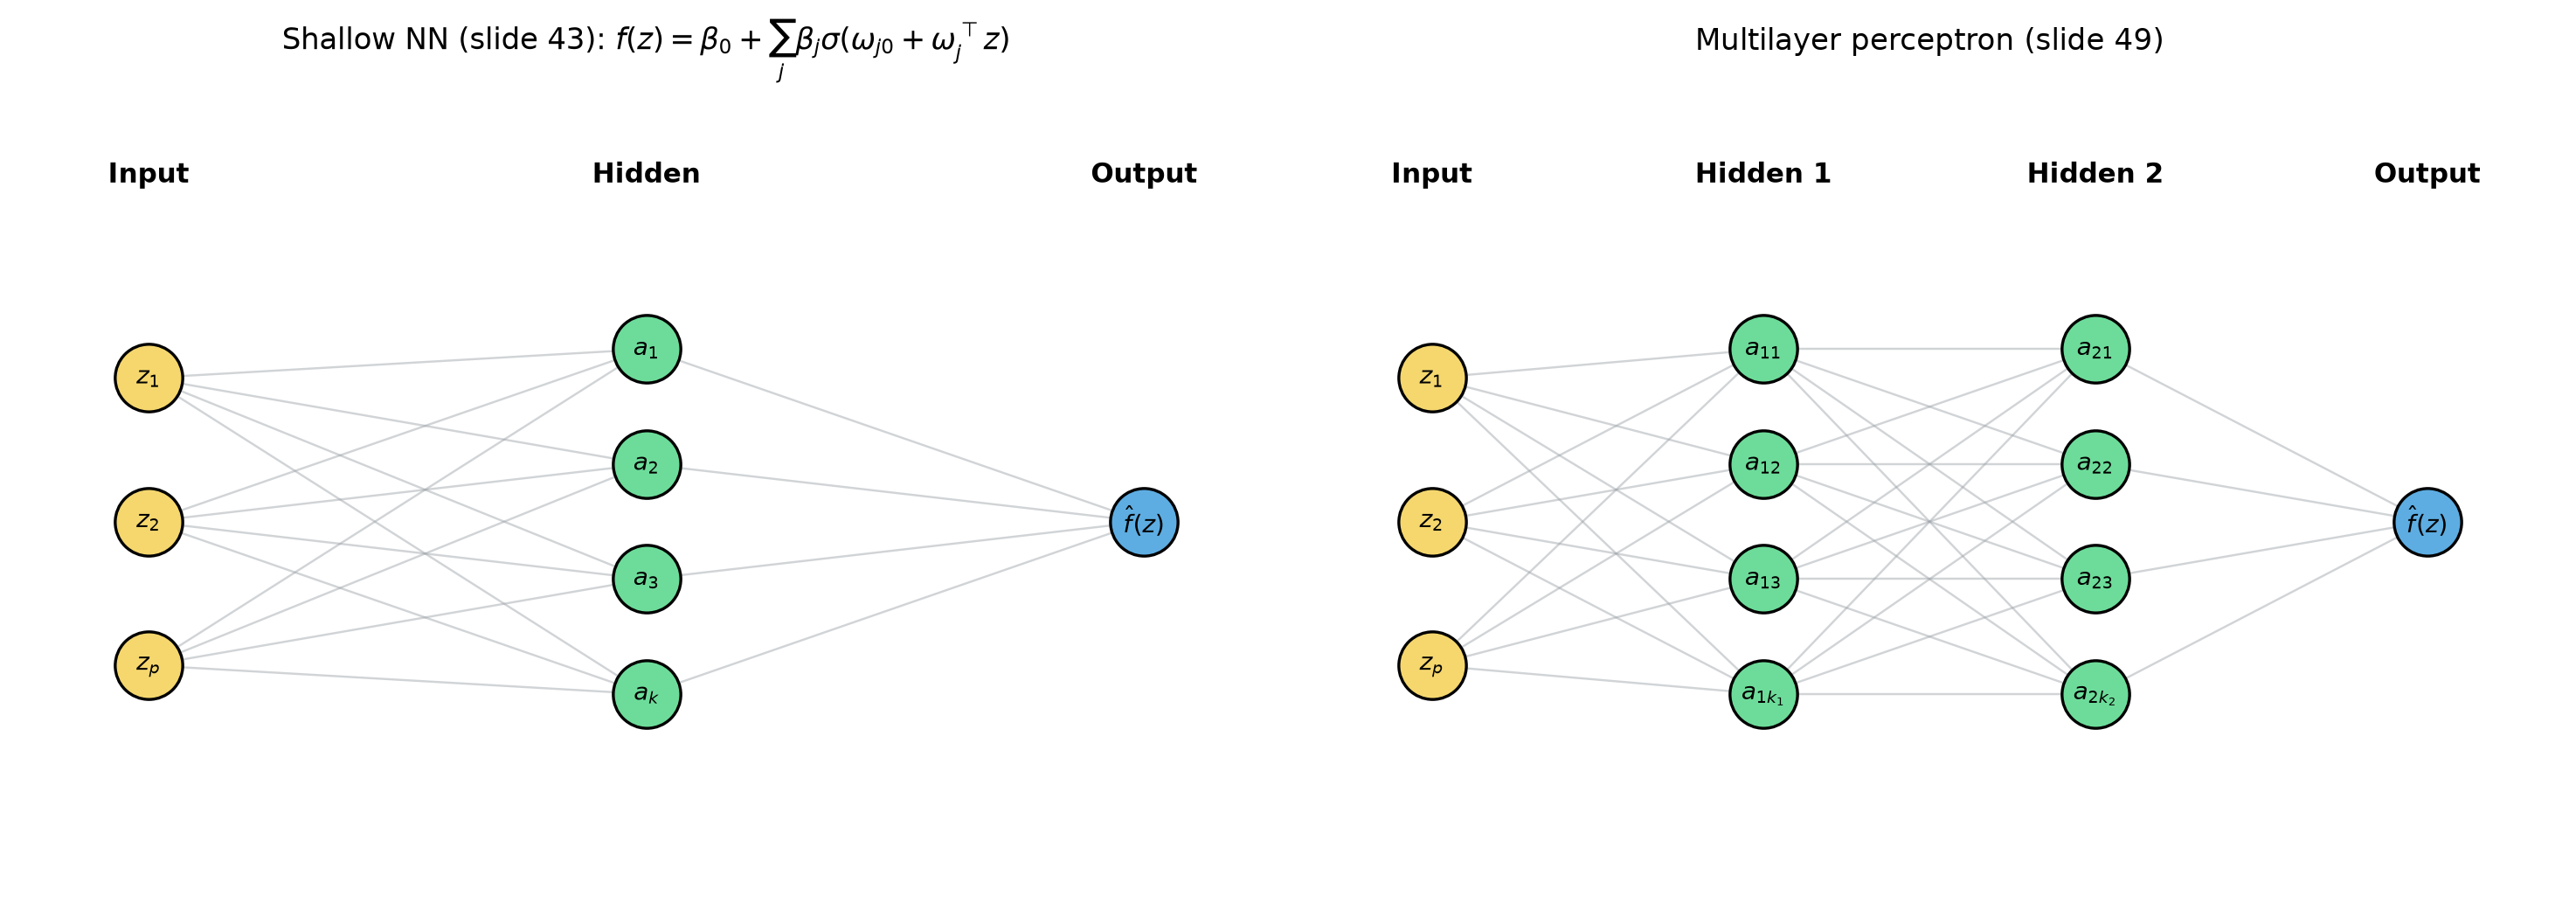

In [45]:
def draw_network(layer_sizes, weights=None, layer_names=None, node_labels=None,
                 title=None, max_show=7, ax=None, figsize=(9, 5)):
    """Draw a feedforward architecture.

    layer_sizes : list of ints, e.g. [3, 5, 4, 1]
    weights     : optional list of arrays, weights[l] has shape (n_l, n_{l+1}).
                  Blue = positive, red = negative, thickness = |weight|.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    L  = len(layer_sizes)
    xs = np.linspace(0, 1, L)
    pos = []
    for li, n in enumerate(layer_sizes):
        ns = min(n, max_show)
        ys = np.linspace(0, 1, ns + 2)[1:-1][::-1] if ns > 1 else np.array([0.5])
        pos.append(np.column_stack([np.full(ns, xs[li]), ys]))

    for li in range(L - 1):
        W = None if weights is None else np.asarray(weights[li])
        wmax = 1.0 if W is None else (np.abs(W).max() + 1e-12)
        for i, p in enumerate(pos[li]):
            for j, q in enumerate(pos[li + 1]):
                if W is not None and i < W.shape[0] and j < W.shape[1]:
                    w = W[i, j]; r = abs(w) / wmax
                    lw, col, alp = 0.25 + 3.2 * r, ("#c0392b" if w < 0 else "#2471a3"), 0.15 + 0.7 * r
                else:
                    lw, col, alp = 0.8, "#9aa0a6", 0.45
                ax.plot([p[0], q[0]], [p[1], q[1]], lw=lw, color=col, alpha=alp, zorder=1)

    cols = ["#f5d76e"] + ["#6ddc9a"] * (L - 2) + ["#5dade2"]
    for li, P in enumerate(pos):
        ax.scatter(P[:, 0], P[:, 1], s=640, color=cols[li],
                   edgecolor="k", linewidth=1.1, zorder=3)
        if node_labels and li < len(node_labels) and node_labels[li]:
            for k_, pt in enumerate(P):
                if k_ < len(node_labels[li]):
                    ax.text(pt[0], pt[1], node_labels[li][k_], ha="center",
                            va="center", fontsize=9, zorder=4)
        if layer_sizes[li] > len(P):
            ax.text(P[0, 0], -0.055, f"$\\vdots$ (+{layer_sizes[li]-len(P)})",
                    ha="center", fontsize=8, color="dimgray")
    if layer_names:
        for li, nm in enumerate(layer_names):
            ax.text(xs[li], 1.09, nm, ha="center", fontsize=10, weight="bold")
    ax.set_xlim(-0.13, 1.13); ax.set_ylim(-0.13, 1.20)
    ax.axis("off"); ax.grid(False)
    if title:
        ax.set_title(title, pad=26, fontsize=11)
    return ax


fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
draw_network([3, 4, 1], ax=ax[0],
             layer_names=["Input", "Hidden", "Output"],
             node_labels=[["$z_1$", "$z_2$", "$z_p$"],
                          ["$a_1$", "$a_2$", "$a_3$", "$a_k$"], ["$\\hat f(z)$"]],
             title="Shallow NN (slide 43): $f(z)=\\beta_0+\\sum_j \\beta_j\\sigma(\\omega_{j0}+\\omega_j^\\top z)$")
draw_network([3, 4, 4, 1], ax=ax[1],
             layer_names=["Input", "Hidden 1", "Hidden 2", "Output"],
             node_labels=[["$z_1$", "$z_2$", "$z_p$"],
                          ["$a_{11}$", "$a_{12}$", "$a_{13}$", "$a_{1k_1}$"],
                          ["$a_{21}$", "$a_{22}$", "$a_{23}$", "$a_{2k_2}$"], ["$\\hat f(z)$"]],
             title="Multilayer perceptron (slide 49)")
plt.tight_layout(); plt.show()

`⏱ 18–30 min`  ·  **CORE — the centrepiece**

---
# 4. Approximating $\sin$: the universal approximation theorem, visually

### The theory (slides 45–46)

> **Question.** Can shallow networks approximate the target function well?
> **Answer.** Yes, as long as we are free to choose the number of neurons.

**Stone–Weierstrass** says any continuous function is approximable by a polynomial of
high enough order. But $f(z)$ in a neural network is *not* a polynomial, so that theorem
does not apply directly. The result we need is the

> **Universal Approximation Theorem** (Cybenko 1989; Hornik, Stinchcombe & White 1989).
> Any continuous function can be approximated arbitrarily well by a shallow network
> provided (i) the number of hidden units is large enough, and (ii) $\sigma$ is locally
> bounded, piecewise continuous, **and not a polynomial** (Leshno et al. 1993).

### Why "not a polynomial" is the right condition

This condition looks technical and is actually the heart of the matter. If $\sigma$ were a
polynomial of degree $d$, then every $\sigma(\omega_{j0}+\omega_j^\top z)$ is a polynomial of
degree $\le d$, and any finite sum of them is **still** a polynomial of degree $\le d$. No
matter how many neurons you add, you never escape a fixed finite-dimensional space, so
you cannot approximate anything outside it. Non-polynomial $\sigma$ is exactly what makes
the span grow without bound as $k$ grows.

### Why it is almost obvious for ReLU

From §2: each ReLU neuron is a hinge with one kink. A sum of $k$ hinges is a
**piecewise-linear function with at most $k$ kinks**, and the network freely chooses where
every kink goes and what slope follows it. Approximating a smooth curve by a
piecewise-linear one with freely placed knots is something you can do to any accuracy —
just use more knots. **That is the universal approximation theorem for ReLU, in one
sentence.**

Let's watch it happen.


In [46]:
# ---- data: y = sin(2*pi*z) + noise ----
n_obs = 300
z_tr = rng.uniform(-1, 1, n_obs).reshape(-1, 1)
f_true = lambda x: np.sin(2 * np.pi * x)
y_tr = f_true(z_tr).ravel() + 0.10 * rng.normal(size=n_obs)

grid  = np.linspace(-1, 1, 1000).reshape(-1, 1)
g     = grid.ravel()
truth = f_true(g)


def fit_snn(k, Z, Y, n_starts=25, alpha=1e-7):
    """Fit a shallow ReLU net, keeping the best of `n_starts` random initialisations.

    Multiple starts are not a stylistic choice: the objective is nonconvex, so the
    starting value matters a great deal. We quantify exactly how much in section 6.
    """
    best = None
    for s in range(n_starts):
        m = MLPRegressor(hidden_layer_sizes=(k,), activation="relu", solver="lbfgs",
                         alpha=alpha, max_iter=20000, random_state=s, tol=1e-12)
        m.fit(Z, Y)
        loss = np.mean((m.predict(Z) - Y) ** 2)
        if best is None or loss < best[0]:
            best = (loss, m)
    return best[1]


ks = [1, 2, 3, 5, 10, 20, 40]
fits, rows = {}, []
for k in ks:
    m = fit_snn(k, z_tr, y_tr)
    fits[k] = m
    rows.append((k, 3 * k + 1,
                 np.mean((m.predict(z_tr) - y_tr) ** 2),
                 np.mean((m.predict(grid) - truth) ** 2)))

print(f"{'neurons k':>10}{'params':>9}{'train MSE':>12}{'MSE vs TRUE f0':>17}")
print("-" * 48)
for k, npar, tr, tv in rows:
    print(f"{k:>10}{npar:>9}{tr:>12.5f}{tv:>17.5f}")

 neurons k   params   train MSE   MSE vs TRUE f0
------------------------------------------------
         1        4     0.37100          0.38971
         2        7     0.37055          0.38881
         3       10     0.07775          0.07725
         5       16     0.01803          0.01209
        10       31     0.00998          0.00274
        20       61     0.00878          0.00172
        40      121     0.00796          0.00162


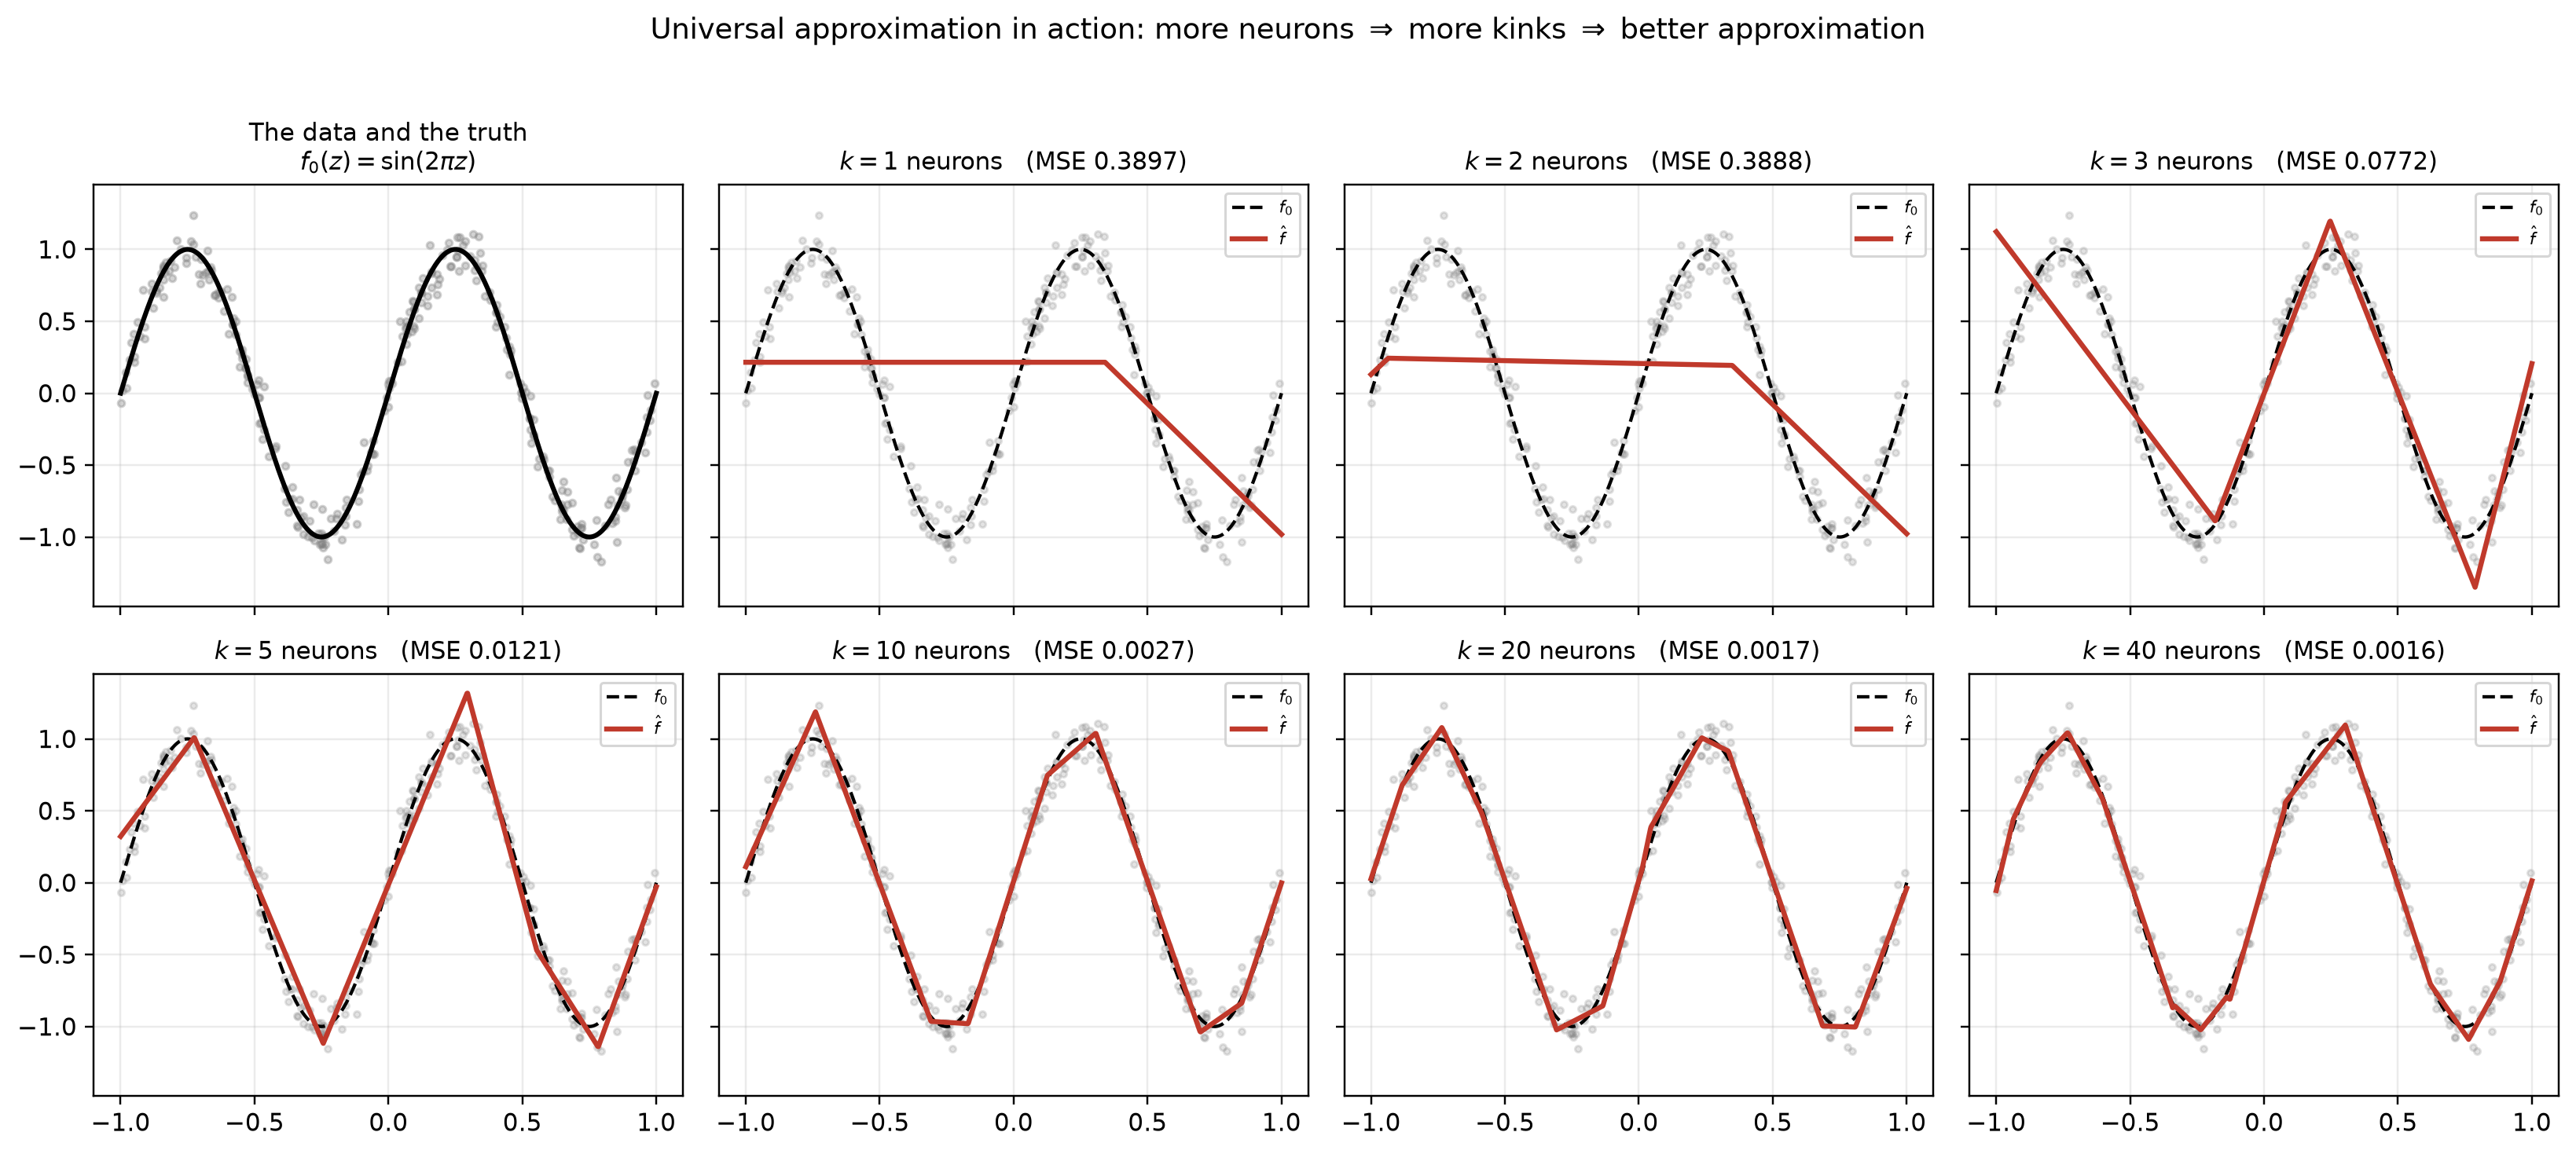

In [47]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True, sharey=True)
axes = axes.ravel()
axes[0].scatter(z_tr, y_tr, s=8, alpha=.35, color="gray")
axes[0].plot(g, truth, "k-", lw=2)
axes[0].set_title("The data and the truth\n$f_0(z)=\\sin(2\\pi z)$", fontsize=10)

for a, k in zip(axes[1:], ks):
    a.scatter(z_tr, y_tr, s=7, alpha=.22, color="gray")
    a.plot(g, truth, "k--", lw=1.4, label="$f_0$")
    a.plot(g, fits[k].predict(grid), lw=2.1, color="#c0392b", label="$\\hat f$")
    a.set_title(f"$k={k}$ neurons   (MSE {np.mean((fits[k].predict(grid)-truth)**2):.4f})",
                fontsize=10)
    a.legend(fontsize=7, loc="upper right")
plt.suptitle("Universal approximation in action: more neurons $\\Rightarrow$ more kinks "
             "$\\Rightarrow$ better approximation", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

Read the panels left to right and the theorem is visible:

- $k=1,2$: one or two kinks cannot bend around a full sine period. Severe **approximation
  error** — the model class is too small.
- $k=3$: the first genuinely sine-shaped fit appears.
- $k=10$ onward: visually indistinguishable from the truth.
- $k=40$ is **not** better than $k=20$. Approximation error has stopped binding; what is
  left is noise. More capacity now buys variance, not accuracy. This is the
  bias–variance trade-off you know, appearing in the one place where it is easy to see.

### Opening the box: a network is literally a sum of hinges

Let's take the fitted $k=5$ network apart and confirm it is nothing more than
$\beta_0 + \sum_j \beta_j a_j$ with $a_j$ the hinges from §2. We reconstruct the prediction
by hand from the weight matrices and check it matches `predict` **exactly**.


`✂ CUT FIRST if behind — the plot below says the same thing`



In [48]:
m5 = fits[5]
W1 = m5.coefs_[0].ravel()        # input -> hidden weights, omega_{j1}
b1 = m5.intercepts_[0]           # hidden biases,           omega_{j0}
W2 = m5.coefs_[1].ravel()        # hidden -> output,        beta_j
b2 = float(m5.intercepts_[1][0]) # output bias,             beta_0

A      = relu(b1[None, :] + g[:, None] * W1[None, :])   # (1000, 5) activations
manual = b2 + A @ W2                                     # the formula from slide 43
sk     = m5.predict(grid)

print("Hand-computed from the formula vs. sklearn's predict:")
print("   max absolute difference =", np.abs(manual - sk).max())
print()
kinks = -b1 / W1
order = np.argsort(kinks)
print(f"{'neuron':>7}{'omega_j0':>11}{'omega_j1':>11}{'beta_j':>10}{'kink -w0/w1':>14}")
print("-" * 54)
for j in order:
    print(f"{j+1:>7}{b1[j]:>11.3f}{W1[j]:>11.3f}{W2[j]:>10.3f}{kinks[j]:>14.3f}")
print(f"\nOutput bias beta_0 = {b2:.3f}")

Hand-computed from the formula vs. sklearn's predict:
   max absolute difference = 0.0

 neuron   omega_j0   omega_j1    beta_j   kink -w0/w1
------------------------------------------------------
      1      1.750      2.415    -2.868        -0.725
      5     -0.592     -2.431     3.685        -0.243
      4      0.914     -3.104    -3.692         0.295
      2     -1.057      1.910     2.089         0.553
      3     -2.002      2.556     3.157         0.783

Output bias beta_0 = 8.382


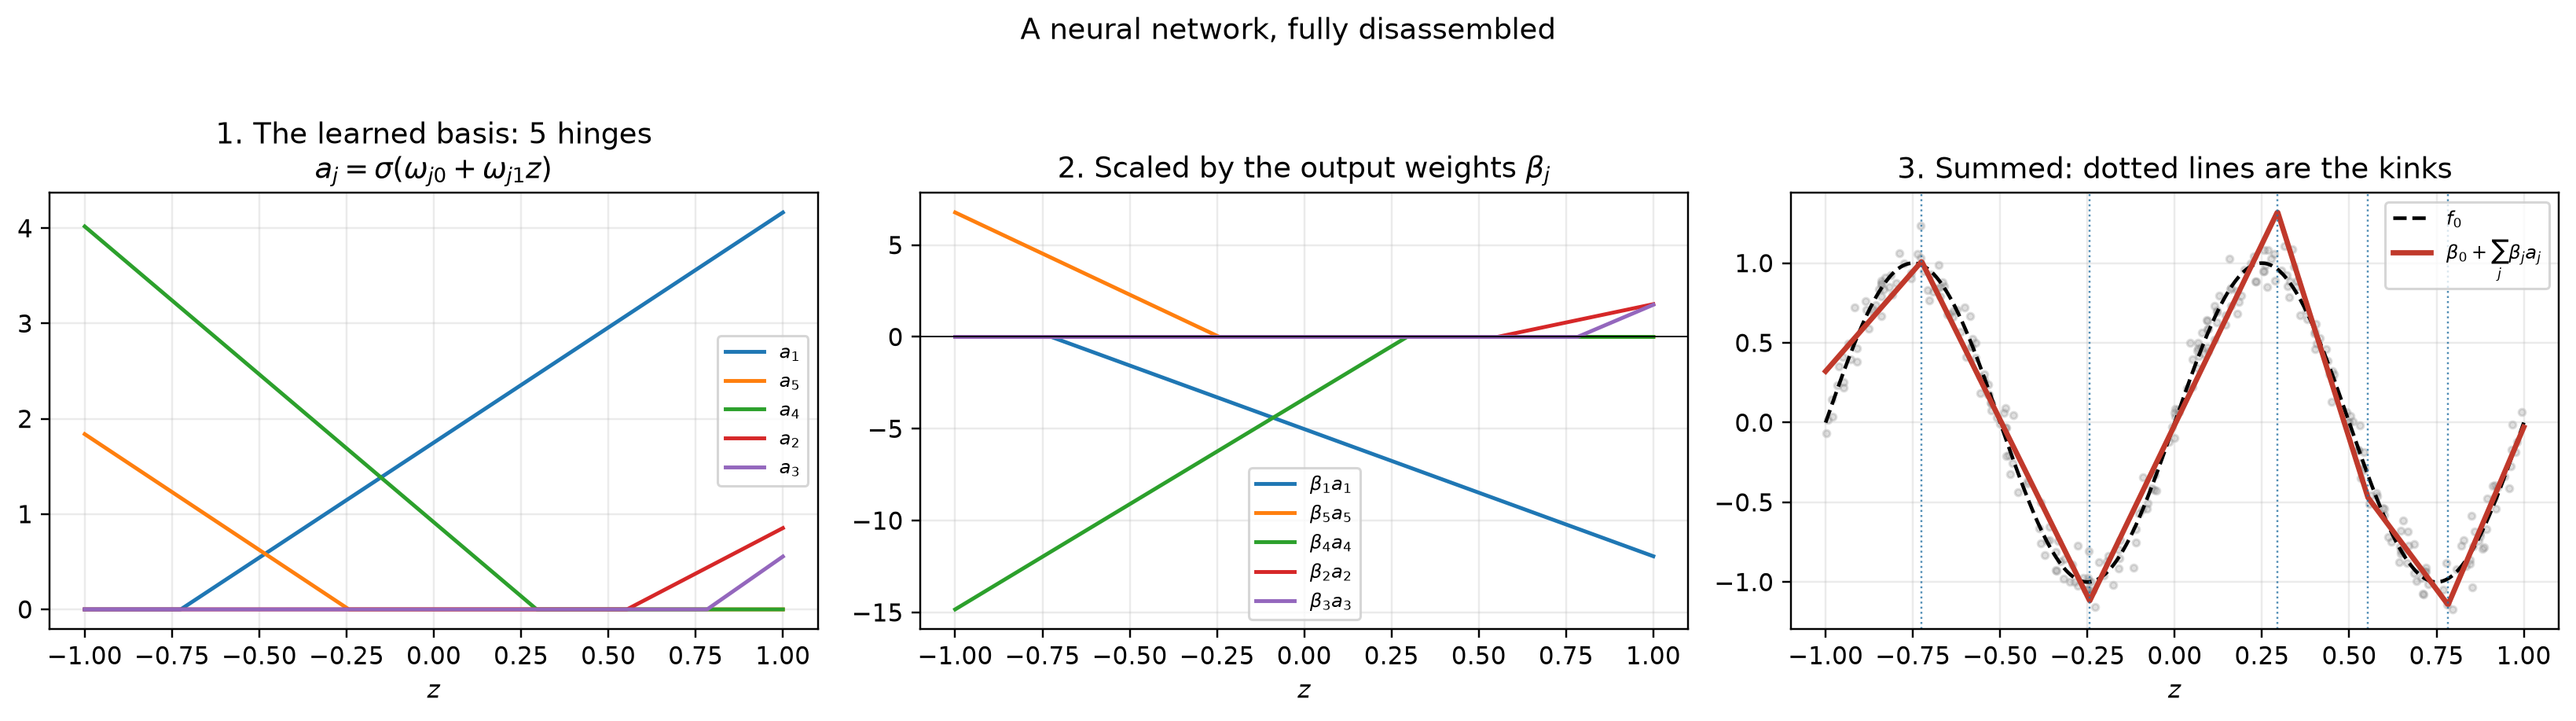

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for j in order:
    ax[0].plot(g, A[:, j], lw=1.6, label=f"$a_{j+1}$")
ax[0].set_title("1. The learned basis: 5 hinges\n$a_j=\\sigma(\\omega_{j0}+\\omega_{j1}z)$")
ax[0].legend(fontsize=8); ax[0].set_xlabel("$z$")

for j in order:
    ax[1].plot(g, W2[j] * A[:, j], lw=1.6, label=f"$\\beta_{j+1}a_{j+1}$")
ax[1].axhline(0, color="k", lw=.6)
ax[1].set_title("2. Scaled by the output weights $\\beta_j$")
ax[1].legend(fontsize=8); ax[1].set_xlabel("$z$")

ax[2].scatter(z_tr, y_tr, s=8, alpha=.25, color="gray")
ax[2].plot(g, truth, "k--", lw=1.5, label="$f_0$")
ax[2].plot(g, manual, lw=2.2, color="#c0392b", label="$\\beta_0+\\sum_j\\beta_j a_j$")
for kk in kinks[(kinks > -1) & (kinks < 1)]:
    ax[2].axvline(kk, color="#2471a3", lw=.8, ls=":", alpha=.8)
ax[2].set_title("3. Summed: dotted lines are the kinks")
ax[2].legend(fontsize=8); ax[2].set_xlabel("$z$")

plt.suptitle("A neural network, fully disassembled", y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

This is the whole mechanism. The network **placed its own knots** — it was never told
where to bend — and then ran what amounts to a linear regression on them. A cubic spline
with 5 knots you placed by hand would be a fixed-basis competitor; the network chose
placements fitted to the data. That is the adaptive-basis idea from §1, now visible.

> **Appendix A** repeats this exercise on $\exp\{4z\}$ — the figure from slide 46 — where
> the curvature is wildly uneven and you can watch the network crowd its kinks into the
> region that bends hardest.

### The same network, drawn as a graph

Now reuse `draw_network` from §3 with the **estimated** weights. Blue edges are positive,
red negative, thickness is magnitude.


`✂ CUT FIRST if behind`


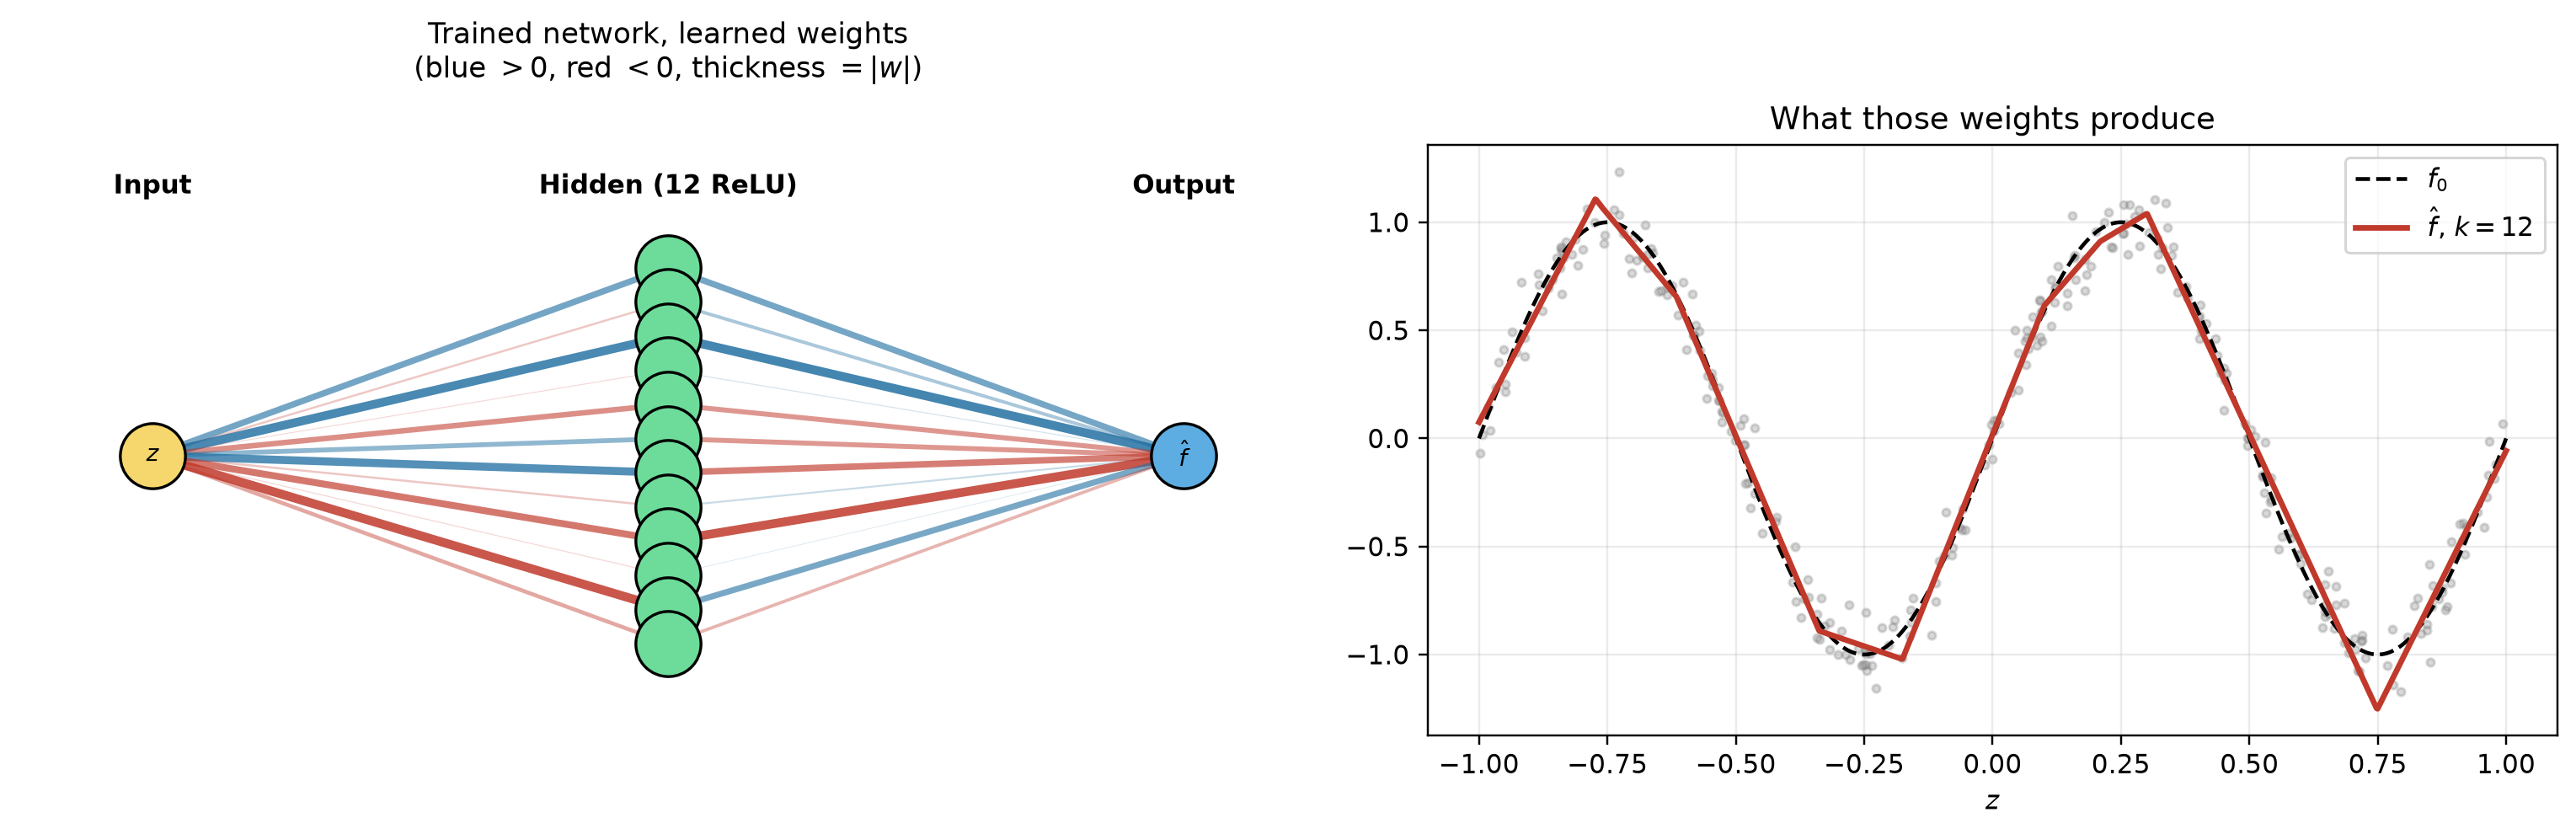

In [50]:
m12 = fit_snn(12, z_tr, y_tr)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6),
                       gridspec_kw={"width_ratios": [1.15, 1]})
draw_network([1, 12, 1], weights=[m12.coefs_[0], m12.coefs_[1]], ax=ax[0],
             layer_names=["Input", "Hidden (12 ReLU)", "Output"],
             node_labels=[["$z$"], None, ["$\\hat f$"]],
             title="Trained network, learned weights\n(blue $>0$, red $<0$, thickness $=|w|$)",
             max_show=12)
ax[1].scatter(z_tr, y_tr, s=9, alpha=.3, color="gray")
ax[1].plot(g, truth, "k--", lw=1.5, label="$f_0$")
ax[1].plot(g, m12.predict(grid), lw=2.2, color="#c0392b", label="$\\hat f$, $k=12$")
ax[1].legend(); ax[1].set_xlabel("$z$"); ax[1].set_title("What those weights produce")
plt.tight_layout(); plt.show()

`⏱ 30–42 min`  ·  **CORE**

---
# 5. Training a neural network (slides 51–52)

### The objective

Write the network as $f(z;\theta)$ where $\theta$ collects **all** weights and biases. Given
data $\{Y_i, Z_i\}_{i=1}^n$ we solve

$$
\min_{\theta}\;\; \underbrace{\frac1n\sum_{i=1}^n\{Y_i - f(Z_i;\theta)\}^2}_{\text{fit}} \;+\; \underbrace{\mathrm{pen}_\lambda(\theta)}_{\text{complexity}}
$$

Structurally this is the same penalized M-estimation problem as LASSO from Lecture 1. In
`scikit-learn`, $\mathrm{pen}_\lambda(\theta) = \alpha\|\theta\|_2^2$ and $\alpha$ is the `alpha`
argument. The slide lists two challenges, and they are of very different kinds:

1. **It is a nonlinear, nonconvex optimization problem.** No closed form, no guarantee of
   a global optimum.
2. **Modern architectures are often highly overparametrized.** More parameters than
   observations.

### Where exactly does the nonconvexity come from?

This is worth pinning down, because the answer is sharper than "neural networks are
nonconvex" and it is genuinely useful.

**Hold the hidden-layer weights $\omega$ fixed.** Then the activations $a_j(z)$ are just fixed
functions of $z$, and

$$
f(z;\theta) = \beta_0 + \sum_{j=1}^k \beta_j a_j(z)
$$

is **linear in $\beta$**. The squared loss is therefore a convex quadratic in $\beta$ — it is
an ordinary least squares problem on the regressors $a_j(z)$, with a closed-form solution.

**Now let $\omega$ vary.** The loss depends on $\omega$ *through* $\sigma$, and the composition of
a nonlinear $\sigma$ with the squared loss is not convex.

> **The nonconvexity lives entirely in the hidden layers.** Conditional on the basis, a
> neural network is OLS. Learning the basis is what makes the problem hard.

Let's verify both halves numerically on the smallest possible network,
$f(z) = \beta_0 + \beta_1\,\sigma(\omega_0 + \omega_1 z)$, by brute-force checking the definition
of convexity along random chords.


`✂ CUT FIRST if behind — state the result and show the contour plot`


In [51]:
zz, yy = z_tr.ravel(), y_tr

def R(b0, b1, w0, w1):
    """Objective R(theta) for f(z) = b0 + b1*relu(w0 + w1*z)."""
    return np.mean((yy - (b0 + b1 * relu(w0 + w1 * zz))) ** 2)

def convexity_violations(fun, lo, hi, n_draws=4000, rs=0):
    """Count chords where R(midpoint) > linear interpolation -> evidence of nonconvexity."""
    r = np.random.default_rng(rs); bad = 0
    for _ in range(n_draws):
        p, q = r.uniform(lo, hi), r.uniform(lo, hi)
        t = r.uniform()
        mid = t * p + (1 - t) * q
        if fun(*mid) > t * fun(*p) + (1 - t) * fun(*q) + 1e-9:
            bad += 1
    return bad

v_beta  = convexity_violations(lambda a, b: R(a, b, -0.3, 2.0), [-2, -3], [2, 3])
v_omega = convexity_violations(lambda a, b: R(0.0, 1.0, a, b), [-3, -8], [3, 8])

print("Convexity test (4000 random chords each)")
print(f"  vary OUTPUT weights (beta_0, beta_1), hidden fixed : {v_beta:>4} violations")
print(f"  vary HIDDEN weights (omega_0, omega_1), output fixed: {v_omega:>4} violations")

Convexity test (4000 random chords each)
  vary OUTPUT weights (beta_0, beta_1), hidden fixed :    0 violations
  vary HIDDEN weights (omega_0, omega_1), output fixed:   56 violations


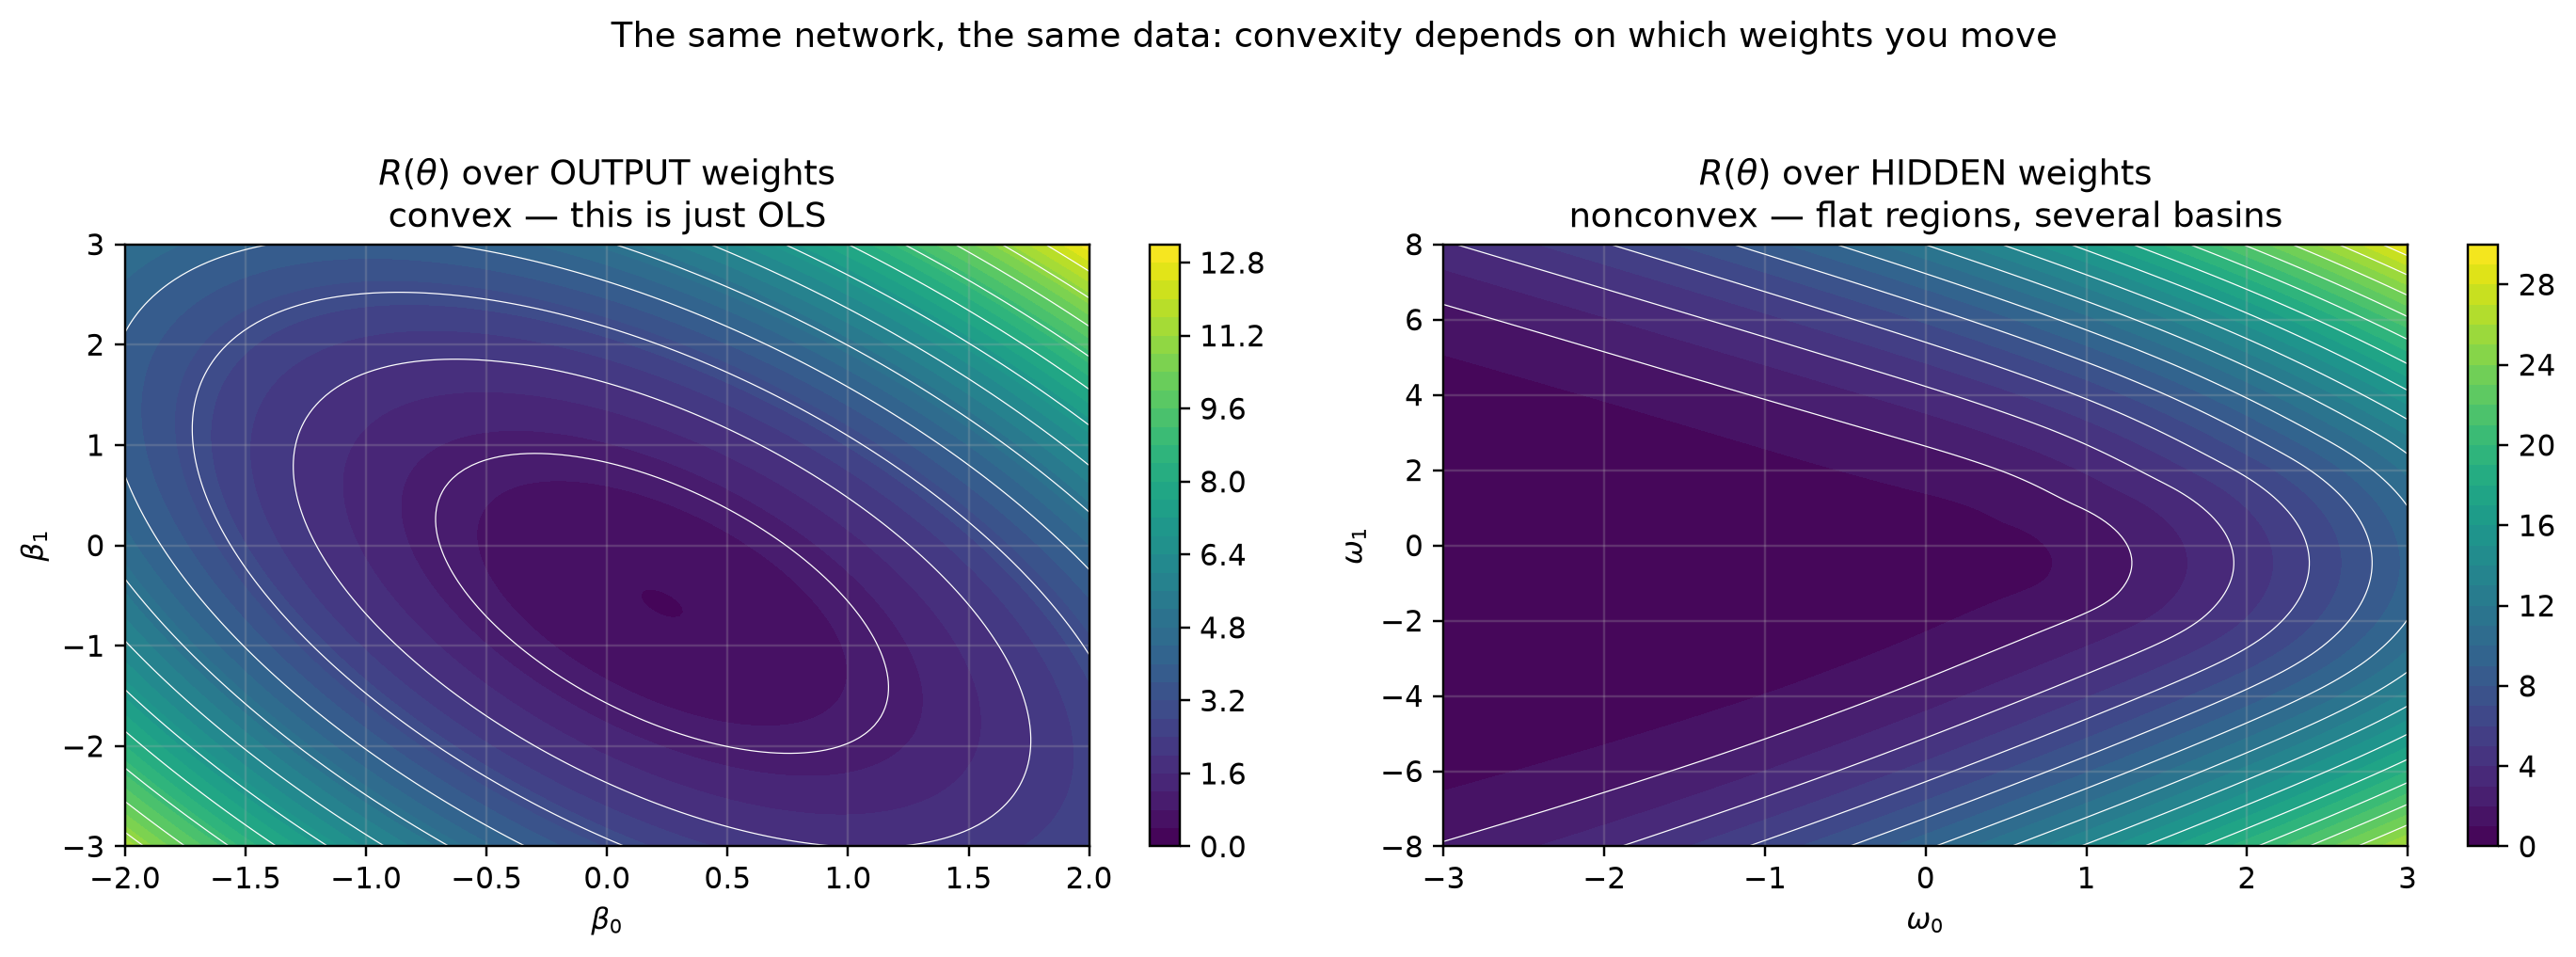

In [52]:
B0, B1 = np.meshgrid(np.linspace(-2, 2, 140), np.linspace(-3, 3, 140))
Ra = np.vectorize(lambda a, b: R(a, b, -0.3, 2.0))(B0, B1)
W0, W1g = np.meshgrid(np.linspace(-3, 3, 170), np.linspace(-8, 8, 170))
Rb = np.vectorize(lambda a, b: R(0.0, 1.0, a, b))(W0, W1g)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
c0 = ax[0].contourf(B0, B1, Ra, 35, cmap="viridis")
ax[0].contour(B0, B1, Ra, 14, colors="w", linewidths=.4)
plt.colorbar(c0, ax=ax[0]); ax[0].set_xlabel("$\\beta_0$"); ax[0].set_ylabel("$\\beta_1$")
ax[0].set_title("$R(\\theta)$ over OUTPUT weights\nconvex — this is just OLS")

c1 = ax[1].contourf(W0, W1g, Rb, 35, cmap="viridis")
ax[1].contour(W0, W1g, Rb, 14, colors="w", linewidths=.4)
plt.colorbar(c1, ax=ax[1]); ax[1].set_xlabel("$\\omega_0$"); ax[1].set_ylabel("$\\omega_1$")
ax[1].set_title("$R(\\theta)$ over HIDDEN weights\nnonconvex — flat regions, several basins")
plt.suptitle("The same network, the same data: convexity depends on which weights you move",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()

The left surface is a clean bowl. The right one has a long flat plateau (where the ReLU
is inactive for most observations, so the gradient is **exactly zero** — a dead neuron)
and more than one basin.

> **Appendix C** follows that observation to its logical end: freeze the hidden layer at
> *random* weights, solve the output layer by plain OLS, and see how close you get.



### Training: Basic Idea (slide 52)

The slide pairs a picture of an objective $R(\theta)$ with this pseudocode:

```
Input: θ⁽⁰⁾ = 0        // initial value of θ; important to try different values
       δ   = 0.001     // step size
       ε   = 0.001     // convergence criterion
       T   = 10,000    // maximum # of iterations
for t ← 1 to T do
    θ⁽ᵗ⁾ ← θ⁽ᵗ⁻¹⁾ + δ
    if R(θ⁽ᵗ⁾) − R(θ⁽ᵗ⁻¹⁾) < ε then
        θ̂ = θ⁽ᵗ⁾ ; break
    end
end
```

Read the update line carefully: $\theta^{(t)} \leftarrow \theta^{(t-1)} + \delta$. We move by a
fixed amount, **always in the same direction**. Nothing in this loop looks at whether the
objective is going up or down.

> **Two things I want to flag, because I am reading a deliberately simplified slide.**
>
> 1. **This is a placeholder, not an algorithm to use.** Taken literally, the update always
>    walks right regardless of what the objective does. The very next slide asks "How to
>    find the directions to move $\theta$ to decrease $R(\theta)$?" and answers it with
>    gradient descent. I read slide 52 as deliberately setting up that question: *iterate,
>    take small steps, stop when you stop improving* — with the **direction left blank**.
> 2. **The stopping rule as written is one-sided.** If a step *decreases* the objective,
>    $R(\theta^{(t)}) - R(\theta^{(t-1)})$ is negative, hence certainly $< \varepsilon$, and the
>    loop breaks. I believe the intent is $|R(\theta^{(t)}) - R(\theta^{(t-1)})| < \varepsilon$:
>    stop when the objective stops *changing*. **Please confirm the intended reading with
>    Professor Fang** — I may be misreading a compressed slide, and the distinction matters
>    for Assignment 2.

Below I run the loop from three different starting values, using the **generous**
$|\cdot|$ version of the stopping rule so we are testing the *update*, not the tolerance.
All three fail, and they fail in three different ways.


In [53]:
def R_scalar(w):
    """Objective as a function of ONE hidden weight; everything else held fixed."""
    return np.mean((yy - relu(-0.3 + w * zz)) ** 2)

def slide52(theta0, delta=0.001, eps=1e-9, T=10000):
    """Slide 52's loop, with the generous |.| stopping rule."""
    th, steps = theta0, 0
    for t in range(1, T + 1):
        new = th + delta
        gap = abs(R_scalar(new) - R_scalar(th))
        th, steps = new, steps + 1
        if gap < eps:
            return th, steps, "stopping rule fired"
    return th, steps, "hit iteration cap T"

ws = np.linspace(-5, 16, 6000)
Rs = np.array([R_scalar(w) for w in ws])
w_star = ws[np.argmin(Rs)]

# the neuron is INACTIVE (output exactly 0 for every observation) in this range
dead_lo, dead_hi = -0.3 / np.abs(zz).max(), 0.3 / np.abs(zz).max()
print(f"At theta = 0 the neuron fires for "
      f"{int((relu(-0.3 + 0.0*zz) > 0).sum())} of {len(zz)} observations.")
print(f"It is completely dead for theta in ({dead_lo:.3f}, {dead_hi:.3f}).\n")

print(f"{'theta(0)':>9}{'theta_hat':>11}{'steps':>8}{'R start':>10}{'R end':>9}   why it stopped")
print("-" * 76)
runs = {}
for th0 in [0.0, -5.0, 5.0]:
    th, st, why = slide52(th0)
    runs[th0] = (th, st, why)
    print(f"{th0:>9.1f}{th:>11.3f}{st:>8}{R_scalar(th0):>10.4f}{R_scalar(th):>9.4f}   {why}")
print(f"\nThe actual minimiser is theta = {w_star:.3f} with R = {R_scalar(w_star):.4f}.")

At theta = 0 the neuron fires for 0 of 300 observations.
It is completely dead for theta in (-0.300, 0.300).

 theta(0)  theta_hat   steps   R start    R end   why it stopped
----------------------------------------------------------------------------
      0.0      0.001       1    0.4856   0.4856   stopping rule fired
     -5.0     -0.299    4701    3.1315   0.4856   stopping rule fired
      5.0     15.000   10000    4.5898  36.9843   hit iteration cap T

The actual minimiser is theta = -1.023 with R = 0.4115.


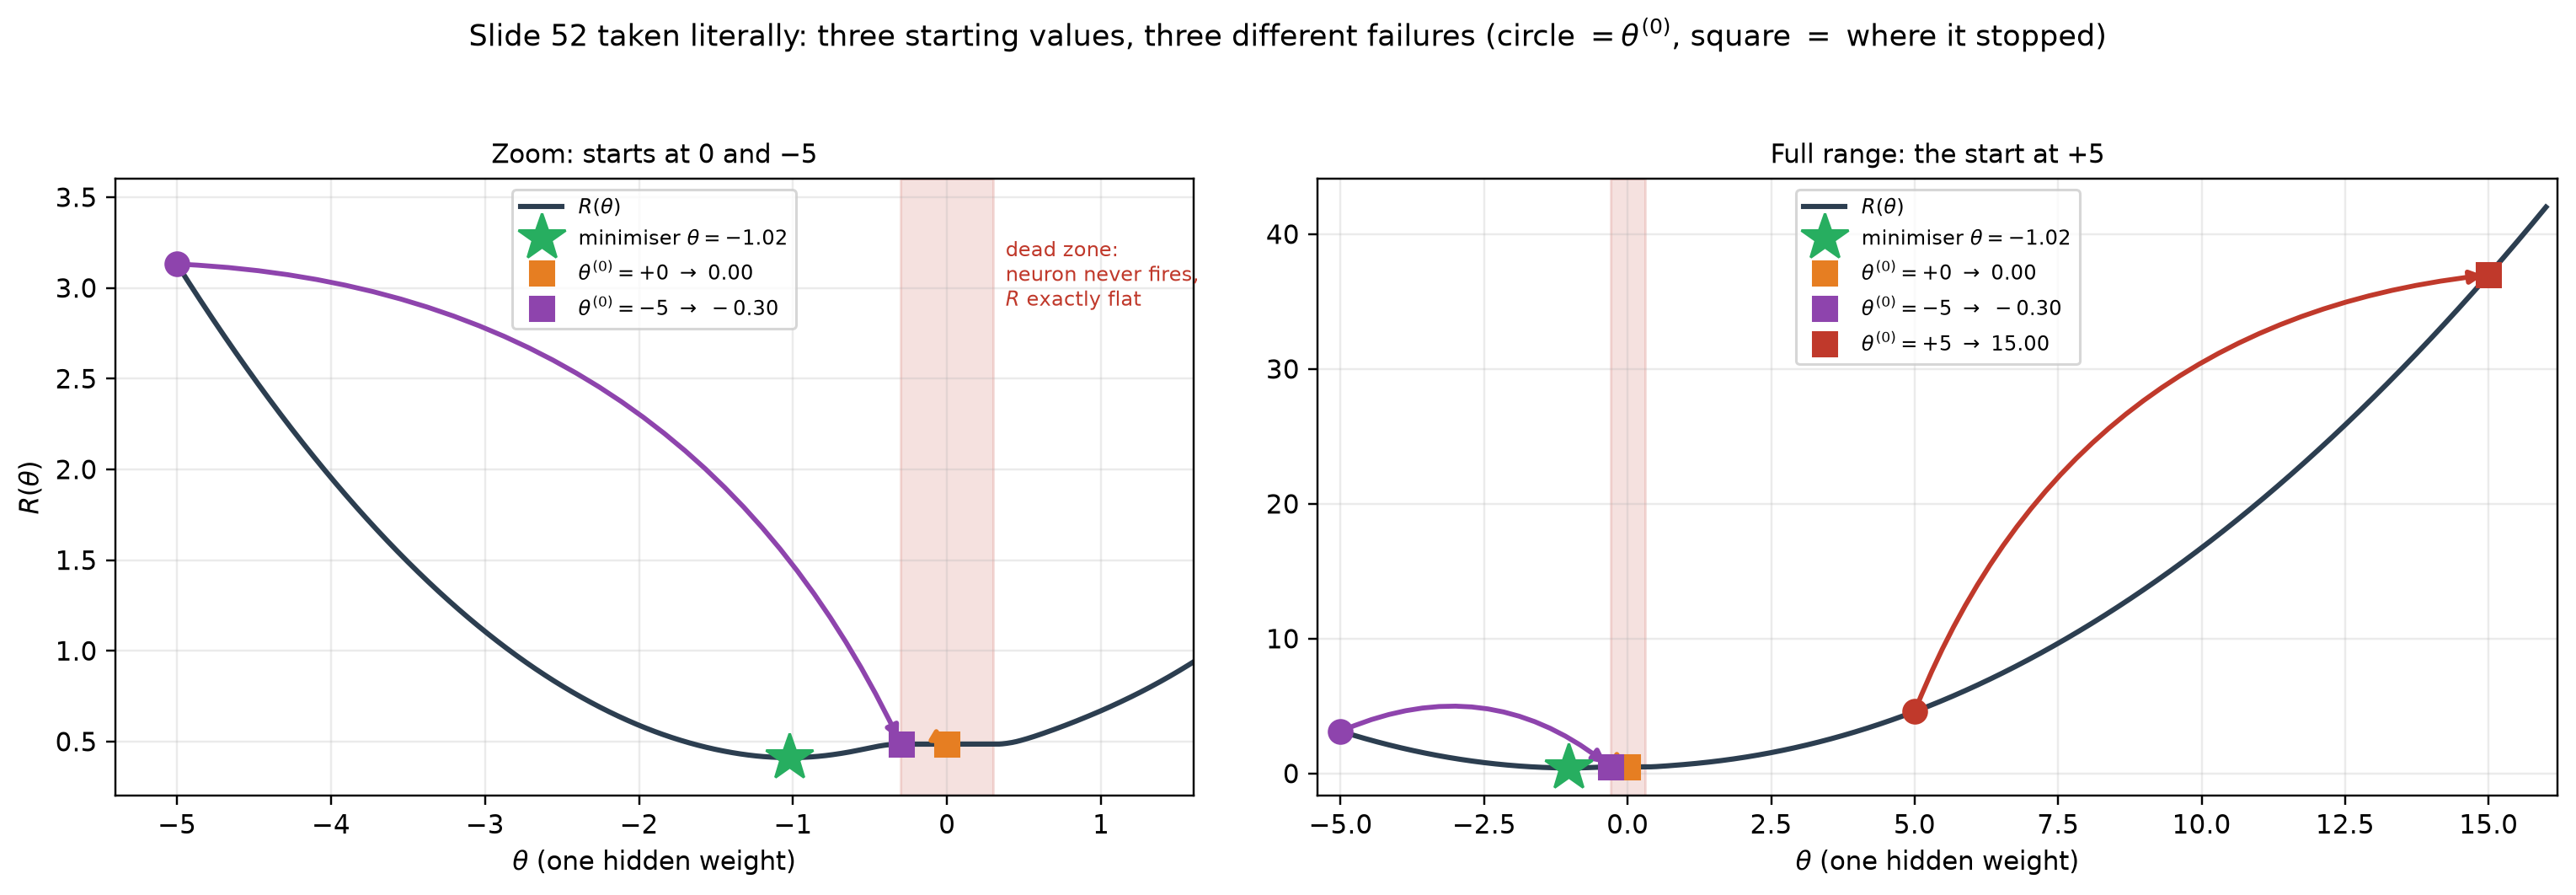

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6),
                       gridspec_kw={"width_ratios": [1, 1.15]})
cols = {0.0: "#e67e22", -5.0: "#8e44ad", 5.0: "#c0392b"}

for a_, (lo, hi, ttl) in zip(ax, [(-5.4, 1.6, "Zoom: starts at $0$ and $-5$"),
                                  (-5.4, 16.2, "Full range: the start at $+5$")]):
    msk = (ws >= lo) & (ws <= hi)
    a_.plot(ws[msk], Rs[msk], lw=2, color="#2c3e50", zorder=2, label="$R(\\theta)$")
    a_.axvspan(dead_lo, dead_hi, color="#c0392b", alpha=.15, zorder=0)
    a_.plot(w_star, R_scalar(w_star), "*", ms=19, color="#27ae60", zorder=6,
            label=f"minimiser $\\theta={w_star:.2f}$")
    for th0, (th_end, st, why) in runs.items():
        if not (lo <= th0 <= hi):
            continue
        c = cols[th0]
        a_.plot(th0, R_scalar(th0), "o", ms=9, color=c, zorder=6)
        a_.plot(th_end, R_scalar(th_end), "s", ms=9, color=c, zorder=6,
                label=f"$\\theta^{{(0)}}={th0:+.0f}\\ \\rightarrow\\ {th_end:.2f}$")
        a_.annotate("", xy=(th_end, R_scalar(th_end)), xytext=(th0, R_scalar(th0)),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=1.9,
                                    connectionstyle="arc3,rad=-0.3"), zorder=5)
    a_.set_xlim(lo, hi); a_.set_xlabel("$\\theta$ (one hidden weight)")
    a_.set_title(ttl, fontsize=10); a_.legend(fontsize=8, loc="upper center")
ax[0].set_ylim(0.2, 3.6); ax[0].set_ylabel("$R(\\theta)$")
ax[0].text(dead_hi + .08, 2.9, "dead zone:\nneuron never fires,\n$R$ exactly flat",
           fontsize=8, color="#c0392b")
plt.suptitle("Slide 52 taken literally: three starting values, three different failures "
             "(circle $=\\theta^{(0)}$, square $=$ where it stopped)", y=1.04, fontsize=11.5)
plt.tight_layout(); plt.show()

Three starts, three distinct ways to fail — and every one of them traces back to the same
missing ingredient.

**Start at $\theta^{(0)} = 0$, the slide's default.** The neuron fires for *zero* of the 300
observations: with bias $-0.3$ and weight $0$, the pre-activation is $-0.3 < 0$ everywhere,
so the ReLU outputs exactly $0$ and $R$ is **exactly flat**. The difference
$R(\theta^{(1)}) - R(\theta^{(0)})$ is not small — it is $0$. The loop halts after a single
step and reports convergence. It has converged to nothing. This is the **dead ReLU**
problem, and it is the same flat plateau you saw in the right-hand contour plot above.

**Start at $\theta^{(0)} = -5$.** Now we walk right and genuinely improve, $R$ falling from
$3.13$ to $0.49$. But the walk **passes straight through the minimiser at $-1.02$** without
noticing — nothing in the loop checks whether the objective started rising again — and
halts at $-0.30$, the edge of the dead zone on the far side. We overshot the optimum and
stopped at a worse point.

**Start at $\theta^{(0)} = +5$.** We walk right, uphill, for all $10{,}000$ iterations and
finish at $\theta = 15$ with an objective **eight times worse** than where we began. The
stopping rule never fires because the objective keeps changing — it is just changing in
the wrong direction.

> **One diagnosis for all three.** The update $\theta^{(t)} \leftarrow \theta^{(t-1)} + \delta$
> specifies a *step size* but no *direction*.

That is precisely the gap the next lecture fills. Gradient descent replaces the update with

$$
\theta^{(t)} \;\leftarrow\; \theta^{(t-1)} - \delta\,\nabla R(\theta^{(t-1)})
$$

where $-\nabla R$ is, by construction, the direction of steepest local decrease. Note what
this fixes in each case: from $+5$ the gradient is positive so we now move *left*; from
$-5$ the gradient flips sign at the minimum so we stop there instead of walking past.
Note also what it does **not** fix: at $\theta^{(0)} = 0$ the gradient is exactly zero, so
gradient descent is stuck there too. Dead units need a different remedy — a better
initialisation, which is exactly why slide 52 says *"important to try different values."*

Everything else in the pseudocode — the step size $\delta$, the tolerance $\varepsilon$, the
iteration cap $T$ — survives into real training unchanged. **Those are the three
hyperparameters you will actually tune.**

### Why the slide says "important to try different values"

That comment on $\theta^{(0)}$ is doing real work. Because the objective is nonconvex, the
starting point determines which basin you land in. Here is the magnitude of the effect:
the same data, the same architecture, 30 different random initialisations.


30 random starts — identical data, identical architecture (k=8)
  best   0.01245
  median 0.13718   (11.0x the best)
  worst  0.41127   (33.0x the best)
  within 10% of the best : 3% of starts
  distinct local optima  : 19 of 30


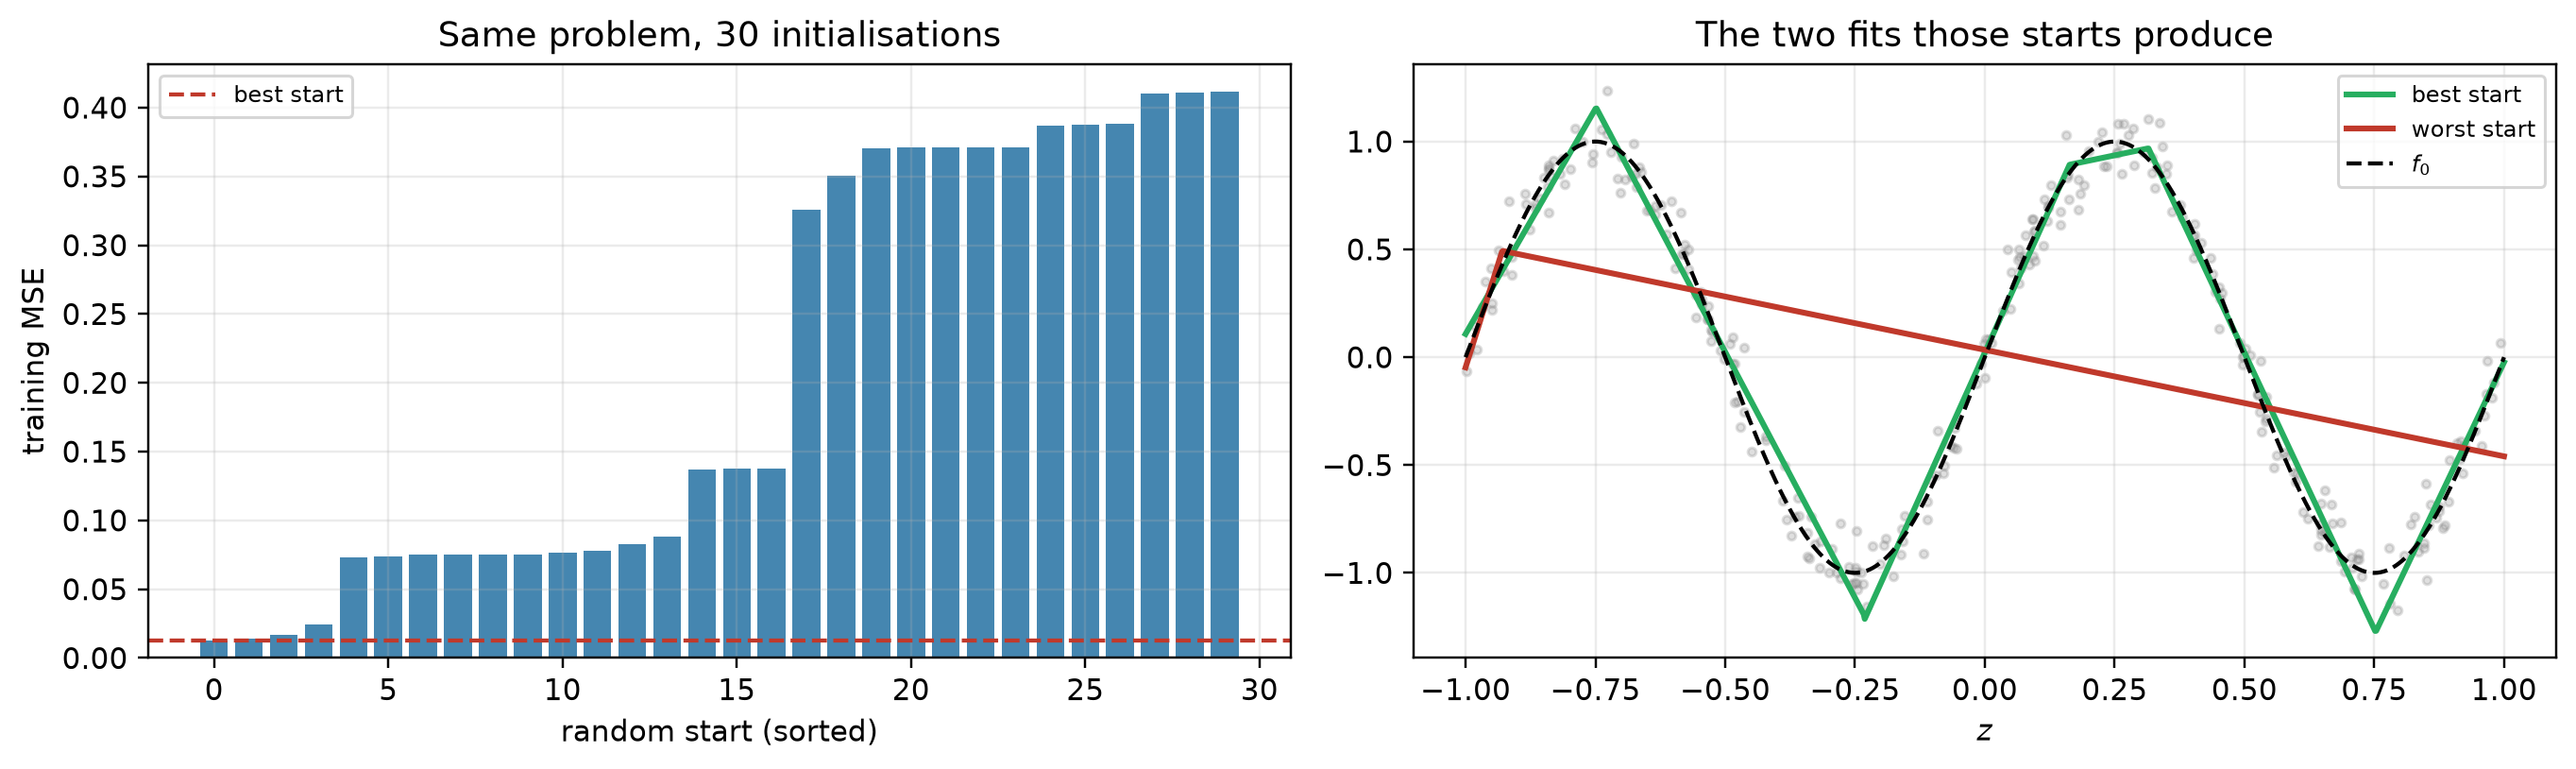

In [55]:
losses = []
for s in range(30):
    m = MLPRegressor(hidden_layer_sizes=(8,), activation="relu", solver="lbfgs",
                     alpha=1e-7, max_iter=20000, random_state=s, tol=1e-12).fit(z_tr, y_tr)
    losses.append(np.mean((m.predict(z_tr) - y_tr) ** 2))
losses = np.array(losses)

print("30 random starts — identical data, identical architecture (k=8)")
print(f"  best   {losses.min():.5f}")
print(f"  median {np.median(losses):.5f}   ({np.median(losses)/losses.min():.1f}x the best)")
print(f"  worst  {losses.max():.5f}   ({losses.max()/losses.min():.1f}x the best)")
print(f"  within 10% of the best : {(losses < 1.1*losses.min()).mean():.0%} of starts")
print(f"  distinct local optima  : {len(set(losses.round(3)))} of 30")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].bar(range(30), np.sort(losses), color="#2471a3", alpha=.85)
ax[0].axhline(losses.min(), color="#c0392b", ls="--", lw=1.4, label="best start")
ax[0].set_xlabel("random start (sorted)"); ax[0].set_ylabel("training MSE")
ax[0].set_title("Same problem, 30 initialisations"); ax[0].legend(fontsize=8)

best_s  = int(np.argmin(losses)); worst_s = int(np.argmax(losses))
for s, c, lab in [(best_s, "#27ae60", "best start"), (worst_s, "#c0392b", "worst start")]:
    mm = MLPRegressor(hidden_layer_sizes=(8,), activation="relu", solver="lbfgs",
                      alpha=1e-7, max_iter=20000, random_state=s, tol=1e-12).fit(z_tr, y_tr)
    ax[1].plot(g, mm.predict(grid), lw=2, color=c, label=lab)
ax[1].scatter(z_tr, y_tr, s=8, alpha=.25, color="gray")
ax[1].plot(g, truth, "k--", lw=1.4, label="$f_0$")
ax[1].legend(fontsize=8); ax[1].set_xlabel("$z$")
ax[1].set_title("The two fits those starts produce")
plt.tight_layout(); plt.show()

Only a small minority of starts land near the best solution, and the worst is many times
worse. **Fitting a neural network once and reporting the result is not a defensible
empirical practice.** Report multiple starts, or fix and report the seed. This is the
practical content of slide 51's "nonconvex," and it is the single most important thing to
take from this section into your own work.


`⏱ 42–48 min`  ·  **CORE**

# 6. Application: sports — expected goals (xG)

Expected-goals models are now standard in football analytics: given where a shot was
taken from, what is the probability it becomes a goal? That is a CEF,
$E[\text{goal} \mid \text{location}]$, and it is strongly nonlinear in raw coordinates.

We simulate shots with a known truth, so we can grade every method against the right
answer. The data-generating process uses two quantities a human analyst would construct
by hand:

$$
\text{dist} = \sqrt{x^2+y^2}, \qquad
\text{angle} = \text{the angle subtended by the 7.32 m goalmouth}
$$

$$
P(\text{goal}) = \Lambda(-0.9 - 0.10\,\text{dist} + 3.0\,\text{angle})
$$

**The models only ever see raw $(x, y)$.** The question is whether a network can recover
the distance-and-angle structure on its own.


In [56]:
GOAL_W = 7.32   # metres

def shot_features(x, y):
    dist = np.sqrt(x**2 + y**2)
    ang  = np.abs(np.arctan2(GOAL_W * x, x**2 + y**2 - (GOAL_W / 2)**2))
    return dist, ang

rs_sp = np.random.default_rng(SEED)
N = 6000
x_sh = rs_sp.uniform(0, 40, N)       # metres out from the goal line
y_sh = rs_sp.uniform(-30, 30, N)     # metres from the centre of the goal
d_sh, a_sh = shot_features(x_sh, y_sh)
p_true = 1 / (1 + np.exp(-(-0.9 - 0.10 * d_sh + 3.0 * a_sh)))
goal = rs_sp.binomial(1, p_true)

Zs = np.column_stack([x_sh, y_sh])              # RAW coordinates only
Fs = np.column_stack([d_sh, a_sh])              # engineered features (oracle)
(Ztr, Zte, Ftr, Fte, gtr, gte, ptr, pte) = train_test_split(
    Zs, Fs, goal, p_true, test_size=.3, random_state=0)

print(f"{N:,} simulated shots, overall conversion rate {goal.mean():.1%}")

models = {
    "Logit on raw (x, y)":  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Ztr, gtr),
    "MLP on raw (x, y)":    make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 32),
                                 activation="relu", alpha=1e-3, max_iter=3000,
                                 random_state=0)).fit(Ztr, gtr),
}
oracle = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Ftr, gtr)

print(f"\n{'model':<26}{'AUC':>8}{'MSE vs TRUE p':>16}")
print("-" * 50)
for nm, mdl in models.items():
    pr = mdl.predict_proba(Zte)[:, 1]
    print(f"{nm:<26}{roc_auc_score(gte, pr):>8.4f}{np.mean((pr - pte)**2):>16.5f}")
pr_o = oracle.predict_proba(Fte)[:, 1]
print(f"{'Oracle logit(dist, angle)':<26}{roc_auc_score(gte, pr_o):>8.4f}{np.mean((pr_o - pte)**2):>16.5f}")
print(f"{'TRUE p (ceiling)':<26}{roc_auc_score(gte, pte):>8.4f}{0.0:>16.5f}")

6,000 simulated shots, overall conversion rate 10.5%

model                          AUC   MSE vs TRUE p
--------------------------------------------------
Logit on raw (x, y)         0.7419         0.02579
MLP on raw (x, y)           0.8418         0.00194
Oracle logit(dist, angle)   0.8497         0.00002
TRUE p (ceiling)            0.8497         0.00000


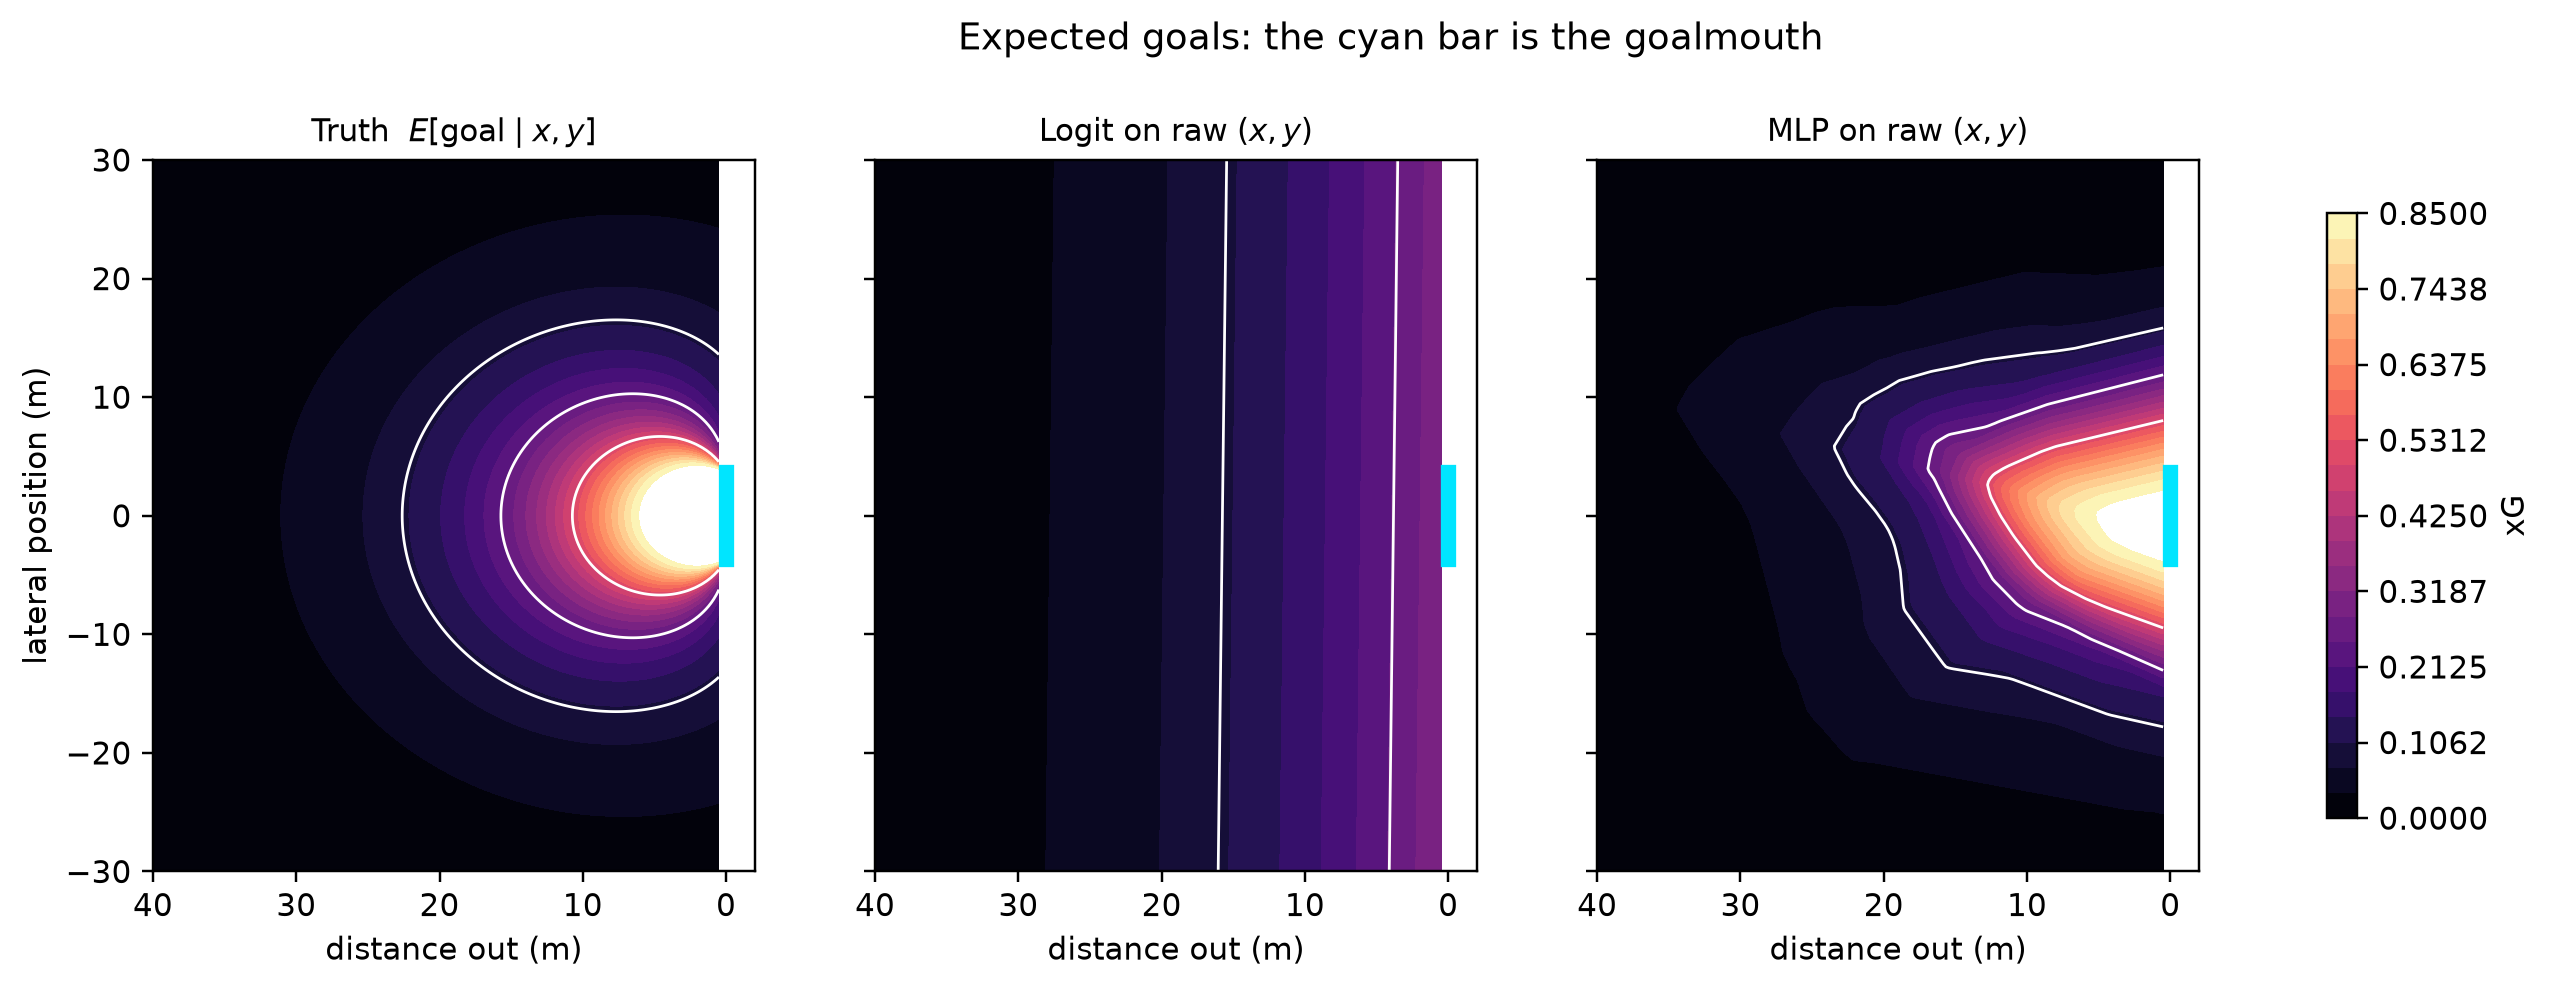

In [57]:
gx, gy = np.meshgrid(np.linspace(0.5, 40, 220), np.linspace(-30, 30, 220))
G_raw = np.column_stack([gx.ravel(), gy.ravel()])
gd, ga = shot_features(gx.ravel(), gy.ravel())
P_true = (1 / (1 + np.exp(-(-0.9 - 0.10 * gd + 3.0 * ga)))).reshape(gx.shape)

surfaces = [("Truth  $E[\\mathrm{goal}\\mid x,y]$", P_true),
            ("Logit on raw $(x,y)$", models["Logit on raw (x, y)"].predict_proba(G_raw)[:, 1].reshape(gx.shape)),
            ("MLP on raw $(x,y)$",   models["MLP on raw (x, y)"].predict_proba(G_raw)[:, 1].reshape(gx.shape))]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for a_, (nm, S) in zip(ax, surfaces):
    im = a_.contourf(gx, gy, S, levels=np.linspace(0, .85, 25), cmap="magma")
    a_.contour(gx, gy, S, levels=[.1, .25, .5], colors="w", linewidths=.9)
    a_.plot([0, 0], [-GOAL_W/2, GOAL_W/2], lw=5, color="#00e5ff")   # the goalmouth
    a_.set_title(nm, fontsize=10); a_.set_xlabel("distance out (m)")
    a_.invert_xaxis(); a_.grid(False)
ax[0].set_ylabel("lateral position (m)")
fig.colorbar(im, ax=ax, shrink=.85, label="xG")
plt.suptitle("Expected goals: the cyan bar is the goalmouth", y=1.03, fontsize=12)
plt.show()

**What the pictures show.** The logit's contours are straight lines — they have to be,
because the model is a monotone transformation of a *linear index* in $x$ and $y$. It
cannot represent "close to the goal **and** central", because that is a radial, interactive
shape. The MLP's contours curve around the goalmouth and reproduce the truth closely.

**The numbers.** The MLP, seeing only raw coordinates, gets within a whisker of the
*oracle* logit that was handed the correct distance and angle features — and it closes
almost the entire gap between the raw logit and the ceiling.

> **The econometric lesson.** The oracle logit is still the better model: it is more
> precise, it is interpretable, and its coefficients mean something. The network's value
> is that **it found that structure without being told it**. In a setting where you know
> the right transformation, use it. In a setting where you have 200 covariates and no
> theory about which interactions matter, a network searches that space for you. That is
> the trade: interpretability for automatic feature discovery.


---
`⏱ 48–50 min`  ·  **CORE — close**

# 7. Bridge: everything above, scaled up

Two minutes, and then we stop. The rest of the notebook is the same machinery with
bigger numbers.

| What we built in §2–§5 | What MNIST does in §8 |
|---|---|
| Input $z \in \mathbb{R}$ | Input $z \in \mathbb{R}^{784}$ — a $28\times28$ image flattened |
| $k$ hidden ReLU units | 40 units (`sklearn`) or 98 units (PyTorch) |
| Scalar output $\hat f(z)$ | 10 outputs, one per digit, through a softmax |
| Squared loss | Cross-entropy, the classification analogue |
| `alpha` as $\mathrm{pen}_\lambda(\theta)$ | `alpha=1e-4`, and dropout in the PyTorch net |

**Softmax** maps 10 real numbers to 10 probabilities summing to one,
$\hat p_c = e^{u_c}/\sum_{c'}e^{u_{c'}}$. With two classes this is exactly the logistic
link — it is the multinomial logit you know, sitting on top of a learned basis.

**Dropout** (slide 53, just past where we stop) randomly switches off neurons during
training. It is a regularizer in the same family as $\mathrm{pen}_\lambda(\theta)$, applied
to hidden layers during training only — never at validation or test time.

**The closing thought.** With $p = 784$ inputs, the §6 lesson stops being a convenience
and becomes the whole point. Nobody writes down the right transformation of 784 pixel
intensities by hand. The network has to find the basis, because you cannot.


### How many parameters is that?

Worth computing once, because it explains the word *overparametrized* on slide 51. A
fully connected layer going from width $k_{l-1}$ to width $k_l$ has $k_{l-1}k_l$ weights
plus $k_l$ biases. So the count grows **multiplicatively in width** and only additively
in depth.


In [58]:
def count_params(sizes):
    return sum(sizes[i] * sizes[i+1] + sizes[i+1] for i in range(len(sizes) - 1))

archs = [([1, 10, 1], "1 input, 1 hidden layer of 10"),
         ([1, 100, 1], "1 input, 1 hidden layer of 100"),
         ([2, 32, 32, 1], "2 inputs, two layers of 32"),
         ([784, 40, 10], "MNIST, sklearn MLP below"),
         ([784, 98, 10], "MNIST, PyTorch net below")]
print(f"{'architecture':<34}{'parameters':>12}")
print("-" * 46)
for s, nm in archs:
    print(f"{nm:<34}{count_params(s):>12,}")

architecture                        parameters
----------------------------------------------
1 input, 1 hidden layer of 10               31
1 input, 1 hidden layer of 100             301
2 inputs, two layers of 32               1,185
MNIST, sklearn MLP below                31,810
MNIST, PyTorch net below                77,920


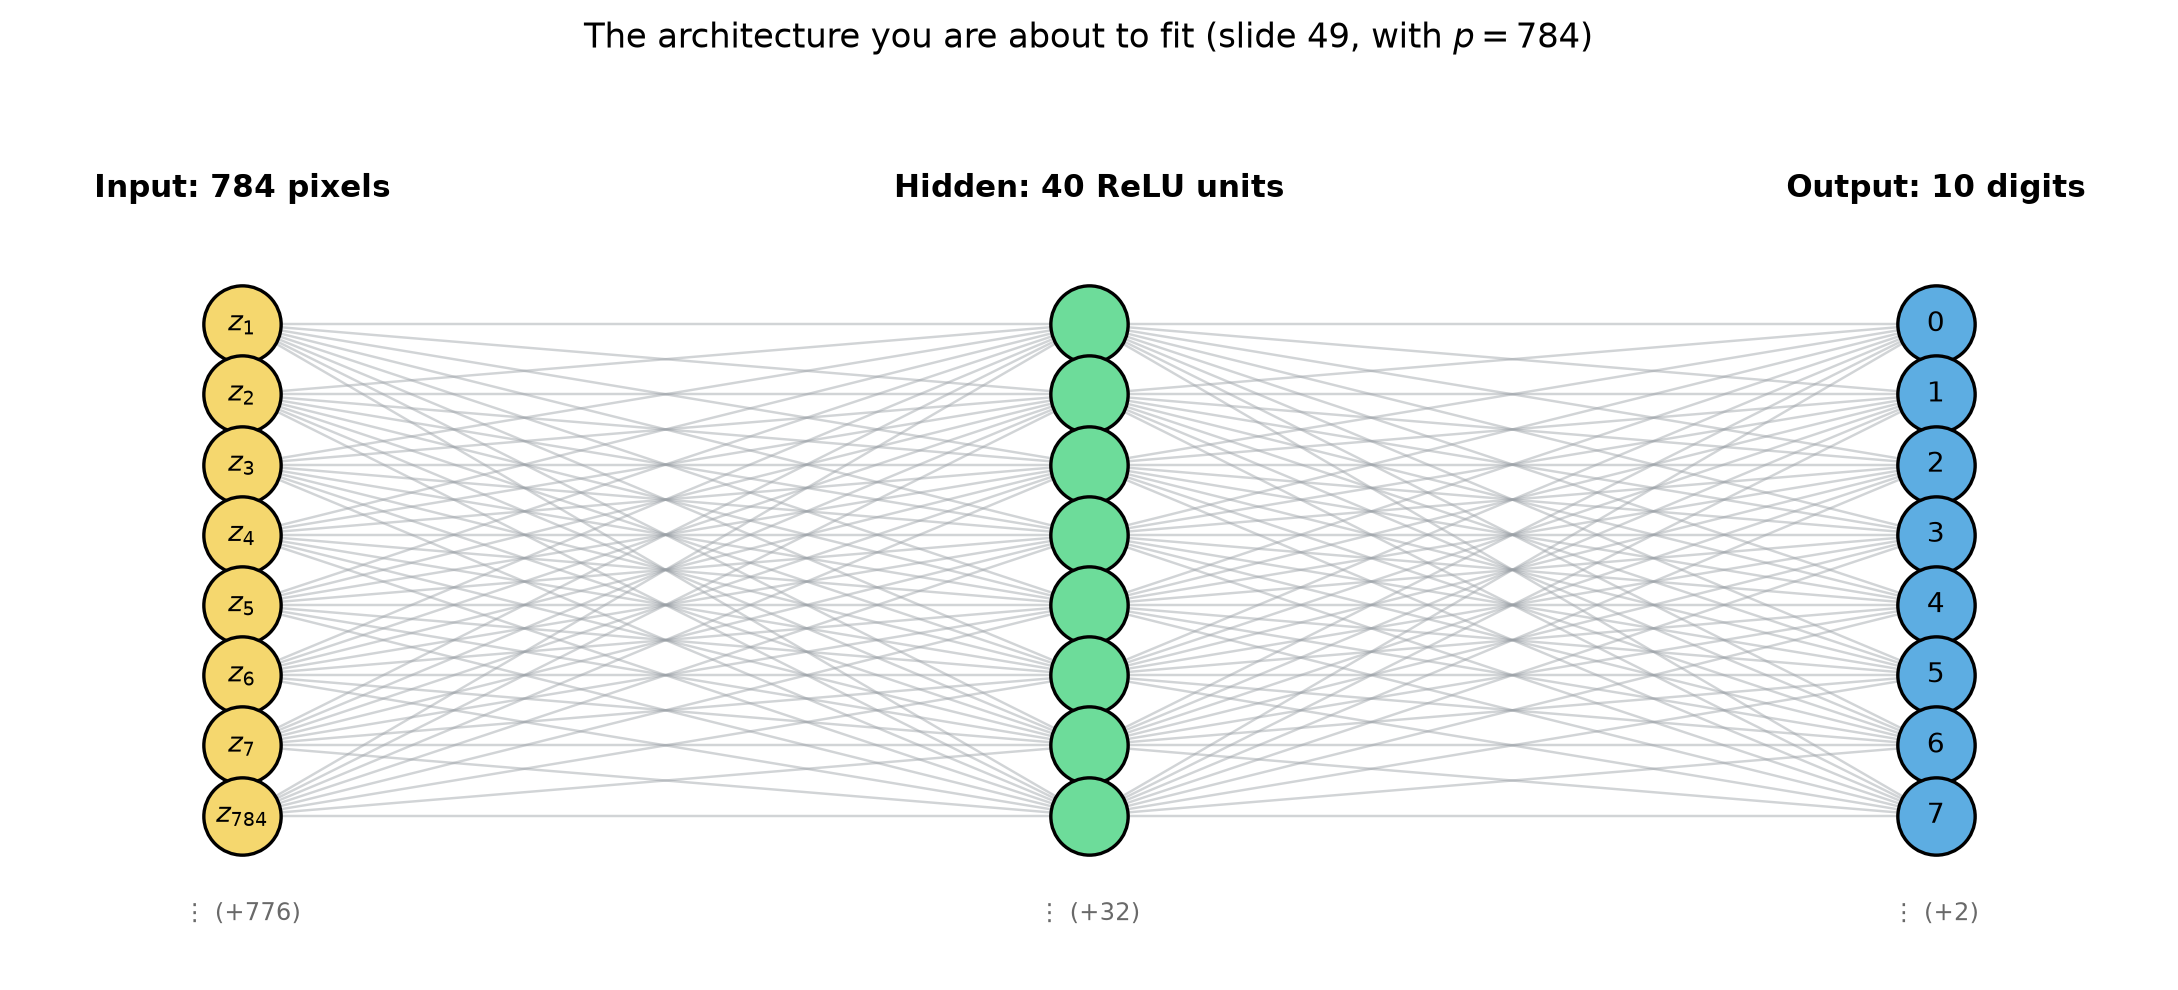

Trainable parameters: 31,810
Training observations in the split below: 21,000
-> more parameters than observations. This is the overparametrized regime of slide 51.


In [59]:
fig, ax = plt.subplots(figsize=(10, 4.6))
draw_network([784, 40, 10], ax=ax, max_show=8,
             layer_names=["Input: 784 pixels", "Hidden: 40 ReLU units", "Output: 10 digits"],
             node_labels=[["$z_1$", "$z_2$", "$z_3$", "$z_4$", "$z_5$", "$z_6$", "$z_7$", "$z_{784}$"],
                          None,
                          ["0", "1", "2", "3", "4", "5", "6", "7"]],
             title="The architecture you are about to fit (slide 49, with $p=784$)")
plt.tight_layout(); plt.show()

print(f"Trainable parameters: {784*40 + 40 + 40*10 + 10:,}")
print("Training observations in the split below: 21,000")
print("-> more parameters than observations. This is the overparametrized regime of slide 51.")

---
`⏱ self-study`  ·  **Demo only if time remains**

# 8. MNIST with `scikit-learn` and PyTorch

*Original lab material, unchanged.*

**Pacing note for the instructor.** If you have two minutes, run down to the
`MLPClassifier` fit — it trains in a few seconds and prints a recognisable accuracy.
Everything from `## Using PyTorch and skorch` onward (20 epochs on CPU) is self-study;
do not start it live unless you have five minutes you do not need.

If the pre-flight cell failed, the `fetch_openml` call below will stall. Skip to the
appendices and assign this section as reading.

---

# Neural Networks

This notebook is a simple introduction to neural networks.

We will first use the `scikit-learn` library to create a simple neural network model to classify the MNIST dataset. For more information, you can check the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

Then, we will use the `pytorch` library to create a more complex neural network model to classify the MNIST dataset. For more information, you can check the [documentation](https://pytorch.org/docs/stable/index.html).

In [60]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Data

We use MNIST dataset which is a dataset of 28x28 pixel handwritten digits, leading to 784 features in the dataset. Therefore the first layer weight matrix has the shape (784, hidden_layer_sizes[0]).

<!-- To make the example run faster, we use very few hidden units, and train only for a very short time. Training longer would result in weights with a much smoother spatial appearance. The example will throw a warning because it doesn’t converge, in this case this is what we want because of resource usage constraints on our Continuous Integration infrastructure that is used to build this documentation on a regular basis. -->

In [61]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load data from https://www.openml.org/d/554
mnist = fetch_openml('mnist_784', as_frame=False, cache=False)
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

# We scale X from [0, 255] to [0, 1].
X /= 255.0

# Split data into train and test partition
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.7)

# Shape of the data
print(f"Data size: {mnist.data.shape}")

Data size: (70000, 784)


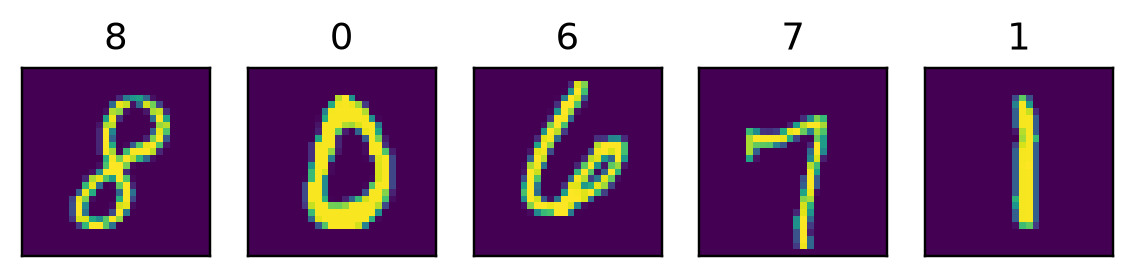

In [62]:
def plot_example(X, y):
    """Plot the first 5 images and their labels in a row."""
    for i, (img, y) in enumerate(zip(X[:5].reshape(5, 28, 28), y[:5])):
        plt.subplot(151 + i)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

plot_example(X_train, y_train)

## Multi-layer Perceptron

Multi-layer Perceptron (MLP) is a supervised learning algorithm that learns a function $f: R^m \rightarrow R^o$ by training on a dataset, where $m$ is the number of dimensions for input and $o$ is the number of dimensions for output.

Given a set of features $X=x_1, x_2, \ldots, x_m$ and a target $y$, it can learn a non-linear function approximator for either classification or regression. It is different from logistic regression, in that between the input and the output layer, there can be one or more non-linear layers, called hidden layers.

<img src="https://scikit-learn.org/1.5/_images/multilayerperceptron_network.png" alt="drawing" width="250"/>

The leftmost layer, known as the input layer, consists of a set of neurons $\left\{x_i \mid x_1, x_2, \ldots, x_m\right\}$ representing the input features.

Each neuron in the hidden layer transforms the values from the previous layer with a weighted linear summation $w_1 x_1+w_2 x_2+\ldots+w_m x_m$, followed by a non-linear activation function $g(\cdot): R \rightarrow R$ - like the hyperbolic tan function.

The output layer receives the values from the last hidden layer and transforms them into output values.

In [63]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(40,),  # number of neurons in the ith hidden layer
    max_iter=8,  # solver iterates until convergence or this number of iterations
    alpha=1e-4,  # L2 penalty (regularization term) parameter
    solver="sgd",  # solver for weight optimization: stochastic gradient descent
    learning_rate_init=0.2,  # controls the step-size in updating the weights
    verbose=True,
    random_state=42,
)

mlp.fit(X_train, y_train)

print("Training set score: %f" % mlp.score(X_train, y_train))
print("Test set score: %f" % mlp.score(X_test, y_test))

Iteration 1, loss = 0.43876687
Iteration 2, loss = 0.18161918
Iteration 3, loss = 0.13374561
Iteration 4, loss = 0.10868500
Iteration 5, loss = 0.09370376
Iteration 6, loss = 0.07700253
Iteration 7, loss = 0.06711734
Iteration 8, loss = 0.05946888
Training set score: 0.988619
Test set score: 0.955735


### Main Parameters
- `hidden_layer_sizes`: The number of neurons in the hidden layer.
- `activation`: The activation function for the hidden layer.
- `solver`: The solver for weight optimization.
- `alpha`: The L2 penalty (regularization term) parameter.
- `learning_rate_init`: It controls the step-size in updating the weights.

### Tips on Practical Use
- Multi-layer Perceptron is sensitive to feature scaling, so it is highly recommended to scale your data.
- Finding a reasonable regularization parameter $\alpha$ is best done using GridSearchCV.
- Empirically, we observed that L-BFGS converges faster and with better solutions on small datasets. For relatively large datasets, however, Adam is very robust.

### Visualizing Neural Networks
To visualize the working of a neural network, we can use [Tensorflow Playground](https://playground.tensorflow.org/), which produced a prediction regression model using a simple single layer neural network model based on two input variables.

## Using PyTorch and skorch

For more information on how to use skorch, you can check the [documentation](https://skorch.readthedocs.io/en/stable/). And for PyTorch, you can check the [documentation](https://pytorch.org/tutorials/beginner/basics/intro.html).

We will build a simple, fully connected neural network with one hidden layer.

Input layer has 784 dimensions (28x28), hidden layer has 98 (= 784 / 8) and output layer 10 neurons, representing digits 0 - 9.

In [64]:
import torch
from torch import nn, optim
import torch.nn.functional as F

mnist_dim = X.shape[1]
hidden_dim = int(mnist_dim/8)
output_dim = len(np.unique(mnist.target))

print(f"Input dim: {mnist_dim}, Hidden dim: {hidden_dim}, Output dim: {output_dim}")

Input dim: 784, Hidden dim: 98, Output dim: 10


To define a neural network in PyTorch, we create a class that inherits from [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).

We define the layers of the network in the `__init__` function and specify how data will pass through the network in the `forward` function. To accelerate operations in the neural network, we move it to the GPU or MPS if available.

In [65]:
class ClassifierModule(nn.Module):
    def __init__(
            self,
            input_dim=mnist_dim,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            dropout=0.5,
    ):
        super(ClassifierModule, self).__init__()
        self.dropout = nn.Dropout(dropout)

        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, **kwargs):
        X = F.relu(self.hidden(X))
        X = self.dropout(X)
        X = F.softmax(self.output(X), dim=-1)
        return X

In [66]:
import skorch

In [67]:
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

net = skorch.NeuralNetClassifier(
    ClassifierModule,
    max_epochs=20,
    lr=0.1,
    device=device,
)

In [68]:
net.fit(X_train, y_train);

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        1.2392       0.8571        0.5637  0.0671
      2        0.6047       0.8933        0.3982  0.0611
      3        0.4972       0.9048        0.3435  0.0609
      4        0.4356       0.9167        0.3049  0.0607
      5        0.3972       0.9238        0.2799  0.0609
      6        0.3666       0.9255        0.2627  0.0612
      7        0.3463       0.9298        0.2488  0.0608
      8        0.3200       0.9319        0.2351  0.0606
      9        0.3140       0.9340        0.2239  0.0609
     10        0.3015       0.9348        0.2203  0.0608
     11        0.2833       0.9410        0.2042  0.0604
     12        0.2689       0.9393        0.1987  0.0605
     13        0.2642       0.9433        0.1934  0.0605
     14        0.2555       0.9452        0.1879  0.0603
     15        0.2467       0.9460        0.1833  0.0601
     16        0.2390       0.9

In [69]:
from sklearn.metrics import accuracy_score

y_pred = net.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9464081632653061


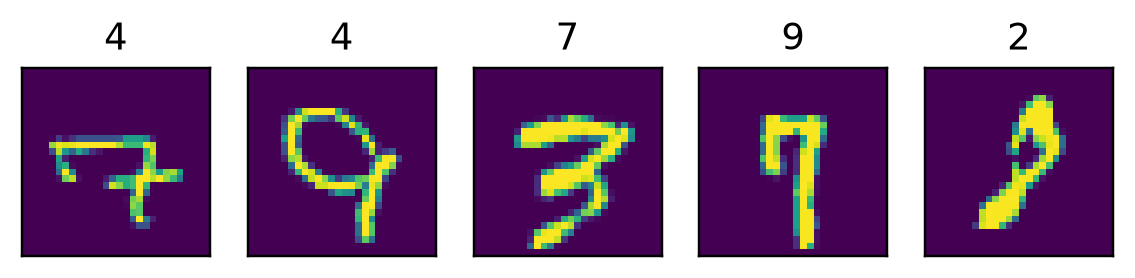

In [70]:
error_mask = y_pred != y_test

plot_example(X_test[error_mask], y_pred[error_mask])

---
---
# Appendices — self-study

Written to be read without an instructor. Each is independent; run the setup cell at the
top of the notebook first, plus §4's data cell, and any appendix will execute on its own.

| | Topic | Slides |
|---|---|---|
| **A** | Approximating $\exp\{4z\}$ | 46 |
| **B** | Depth vs. width | 47–48 |
| **C** | Random features — training without backpropagation | — |
| **D** | Finance: learning an option-pricing surface | — |
| **E** | Health: clinical risk prediction | — |

**Start with D.** It is the one most likely to change how you use these models.


---
## Appendix A — Approximating $\exp\{4z\}$ (slide 46)

Slide 46 shows a shallow ReLU network approximating $\exp\{4z\}$. The exponential is a
good stress test because its curvature is extremely uneven — nearly flat on the left,
exploding on the right — so a good approximation must **concentrate its kinks where the
curvature is**.

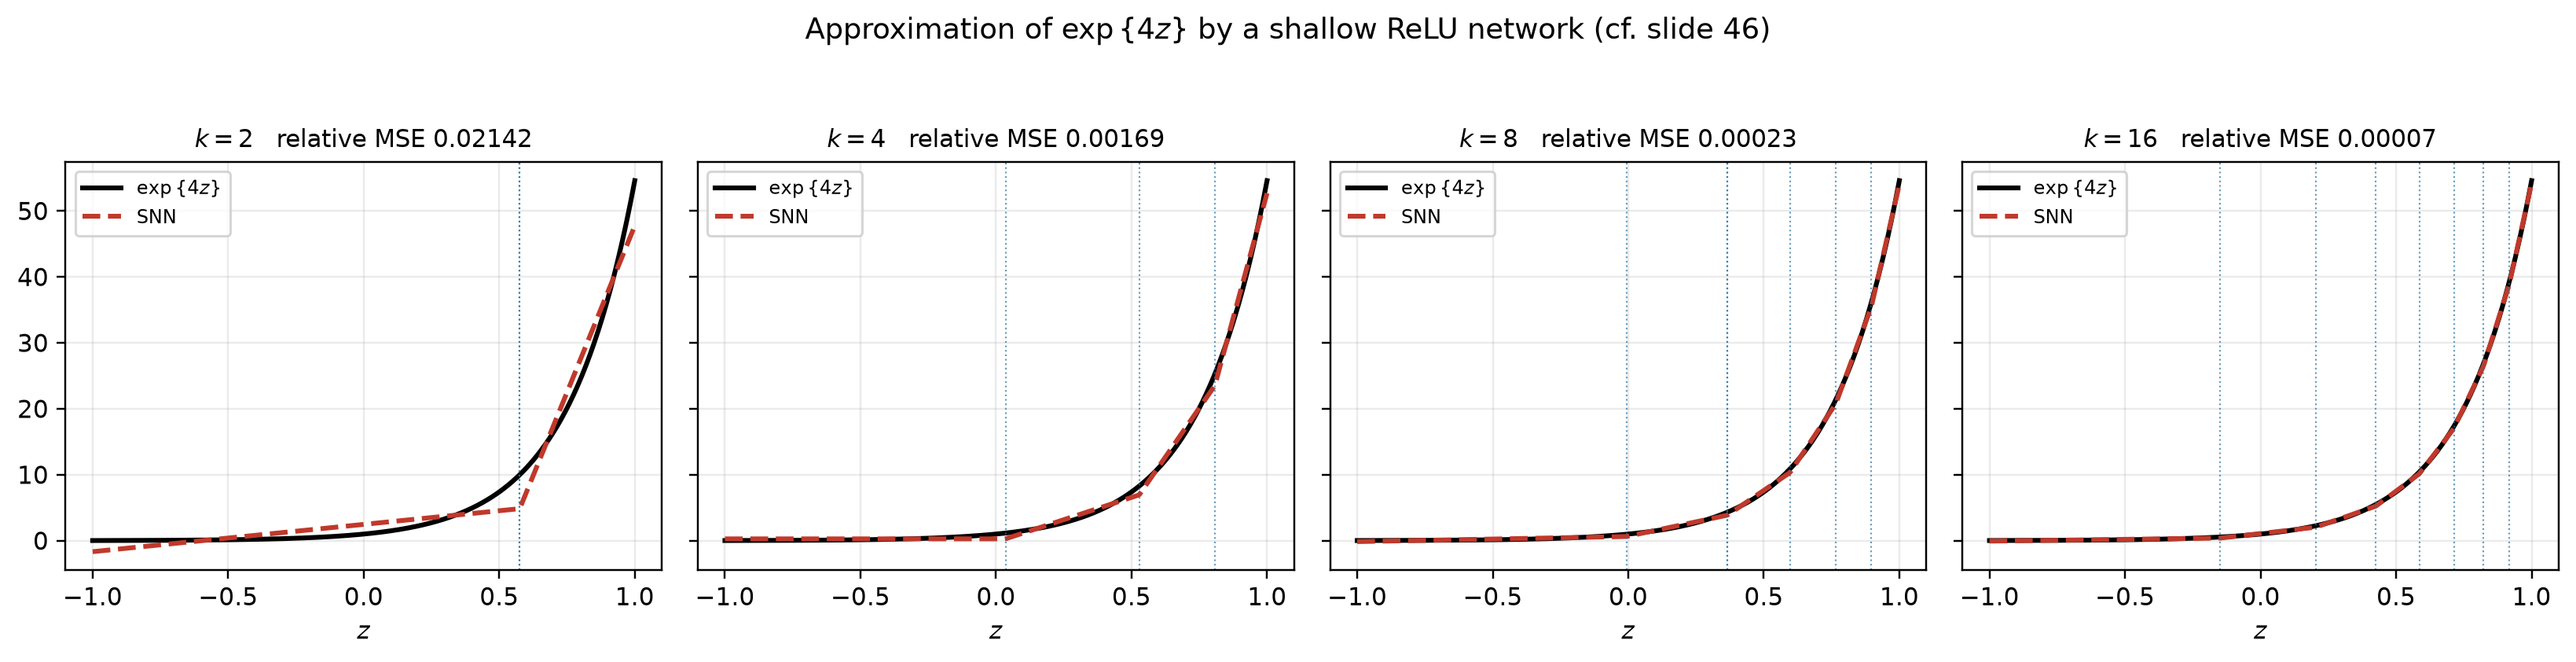

In [71]:
z_e = np.linspace(-1, 1, 400).reshape(-1, 1)
y_e = np.exp(4 * z_e).ravel()

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for a, k in zip(ax, [2, 4, 8, 16]):
    me = fit_snn(k, z_e, y_e, n_starts=12, alpha=1e-8)
    pe = me.predict(z_e)
    a.plot(z_e, y_e, "k-", lw=2, label="$\\exp\\{4z\\}$")
    a.plot(z_e, pe, lw=2, color="#c0392b", ls="--", label="SNN")
    kk = -me.intercepts_[0] / me.coefs_[0].ravel()
    for v in kk[(kk > -1) & (kk < 1)]:
        a.axvline(v, color="#2471a3", lw=.7, ls=":", alpha=.7)
    a.set_title(f"$k={k}$   relative MSE {np.mean((pe-y_e)**2)/np.var(y_e):.5f}", fontsize=10)
    a.legend(fontsize=8); a.set_xlabel("$z$")
plt.suptitle("Approximation of $\\exp\\{4z\\}$ by a shallow ReLU network (cf. slide 46)",
             y=1.05, fontsize=12)
plt.tight_layout(); plt.show()

Notice where the dotted kink lines cluster: **on the right**, where the function bends
hardest. Nobody told the network to do that. Adaptive knot placement is precisely what a
fixed polynomial basis cannot do, and it is the reason neural networks tolerate uneven
smoothness far better than a global polynomial.


---
## Appendix B — Depth vs. width (slides 47–48)

*This is the section that most rewards reading slowly. It also contains the one place in
the notebook where theory and practice visibly disagree.*

In [72]:
def tent(x):
    """One hidden layer of exactly 2 ReLU neurons: h(x) = 2*relu(x) - 4*relu(x-0.5)."""
    return 2 * relu(x) - 4 * relu(x - 0.5)

def deep_sawtooth(x, L):
    """L composed tent layers = 2L neurons in total."""
    t = x.copy()
    for _ in range(L):
        t = tent(t)
    return t

xs = np.linspace(0, 1, 100001)
print(f"{'layers L':>9}{'neurons 2L':>12}{'teeth produced':>16}{'shallow neurons needed':>24}")
print("-" * 62)
for L in range(1, 7):
    t = deep_sawtooth(xs, L)
    d = np.sign(np.diff(t))
    peaks = int(np.sum((d[:-1] > 0) & (d[1:] < 0)))
    print(f"{L:>9}{2*L:>12}{peaks:>16}{2*peaks:>24}")

 layers L  neurons 2L  teeth produced  shallow neurons needed
--------------------------------------------------------------
        1           2               1                       2
        2           4               2                       4
        3           6               4                       8
        4           8               8                      16
        5          10              16                      32
        6          12              32                      64


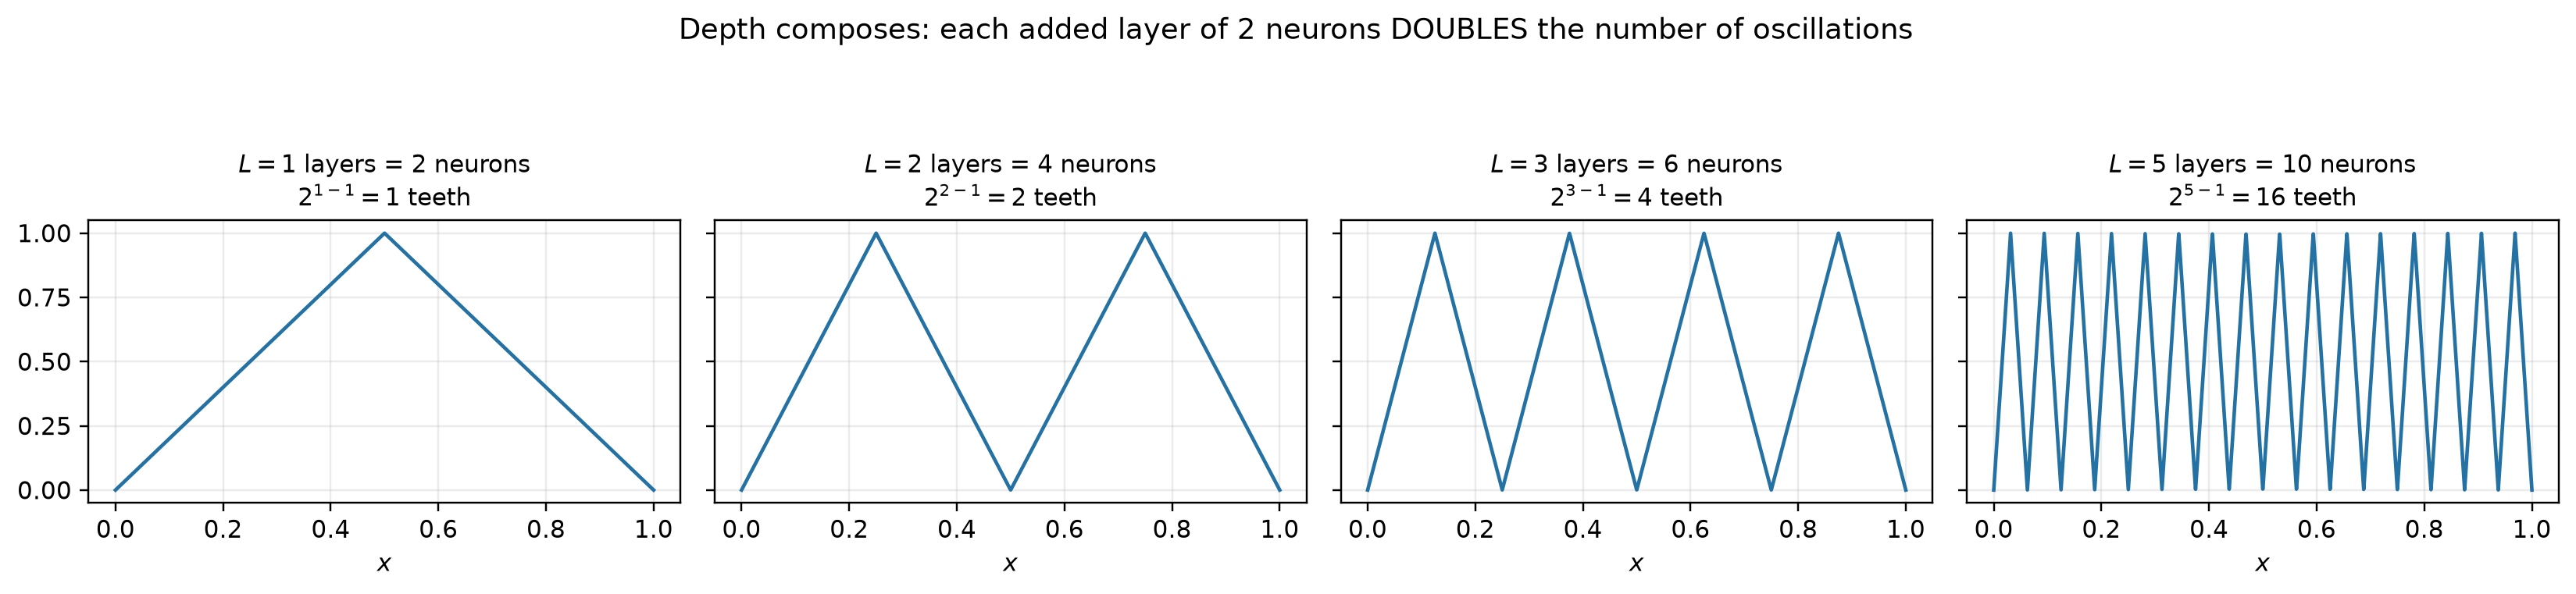

In [73]:
xplot = np.linspace(0, 1, 4000)
fig, ax = plt.subplots(1, 4, figsize=(15, 3.1), sharey=True)
for a, L in zip(ax, [1, 2, 3, 5]):
    a.plot(xplot, deep_sawtooth(xplot, L), lw=1.5, color="#2471a3")
    a.set_title(f"$L={L}$ layers = {2*L} neurons\n$2^{{{L}-1}}={2**(L-1)}$ teeth", fontsize=10)
    a.set_xlabel("$x$")
plt.suptitle("Depth composes: each added layer of 2 neurons DOUBLES the number of oscillations",
             y=1.10, fontsize=12)
plt.tight_layout(); plt.show()

With $L=5$ the hand-built network uses **10 neurons** and produces 16 teeth (32 linear
pieces). A shallow ReLU network needs at least one neuron per kink, so it would need
**on the order of 31 neurons** — and that gap widens exponentially with $L$.

### An honest warning: representation is not training

> **Flagging this clearly, because it is a place where intuition misleads.** Everything
> above is a statement about what a deep network **can represent**. It says nothing about
> whether an optimizer can **find** those weights from data. I constructed the sawtooth
> weights by hand on purpose.

When I instead *trained* networks on this sawtooth target, deep narrow networks did
**not** beat shallow wide ones — the optimizer failed to discover the composition
structure, even with many random restarts. Run the cell below and see for yourself.

This is a genuine and well-documented gap between approximation theory and practice.
Depth gives you expressive power; whether optimization can cash it in is a separate
question, and it is why slide 51 calls training "essentially a nonlinear nonconvex
optimization problem." That is exactly where we go next.


In [74]:
x_saw = np.linspace(0, 1, 2000).reshape(-1, 1)
y_saw = deep_sawtooth(x_saw, 4).ravel()      # 8 teeth

def fit_arch(hl, X, Y, n_starts=8):
    best = None
    for s in range(n_starts):
        m = MLPRegressor(hidden_layer_sizes=hl, activation="relu", solver="lbfgs",
                         alpha=1e-9, max_iter=20000, random_state=s, tol=1e-12).fit(X, Y)
        L_ = np.mean((m.predict(X) - Y) ** 2)
        if best is None or L_ < best[0]:
            best = (L_, m)
    return best

print("TRAINED networks on an 8-tooth sawtooth (lower MSE is better)")
print(f"{'architecture':<18}{'params':>8}{'train MSE':>12}")
print("-" * 38)
for hl in [(16,), (32,), (64,), (8, 8), (8, 8, 8), (8, 8, 8, 8)]:
    L_, m = fit_arch(hl, x_saw, y_saw)
    npar = sum(c.size for c in m.coefs_) + sum(i.size for i in m.intercepts_)
    print(f"{str(hl):<18}{npar:>8}{L_:>12.5f}")

print("\nBy comparison, the HAND-BUILT 4-layer network (16 neurons) has MSE = "
      f"{np.mean((deep_sawtooth(x_saw.ravel(), 4) - y_saw)**2):.2e}")

TRAINED networks on an 8-tooth sawtooth (lower MSE is better)
architecture        params   train MSE
--------------------------------------
(16,)                   49     0.06822
(32,)                   97     0.03521
(64,)                  193     0.00005
(8, 8)                  97     0.04646
(8, 8, 8)              169     0.04016
(8, 8, 8, 8)           241     0.04219

By comparison, the HAND-BUILT 4-layer network (16 neurons) has MSE = 0.00e+00


---
## Appendix C — Random features: fitting a network without backpropagation

Picking up the observation from §5: if the loss is convex in $\beta$ given $\omega$, what
happens if we simply **do not train** $\omega$ at all?

Random features + OLS  : train MSE 0.00758   MSE vs truth 0.00156
Fully trained k=20 net : train MSE 0.00878   MSE vs truth 0.00172


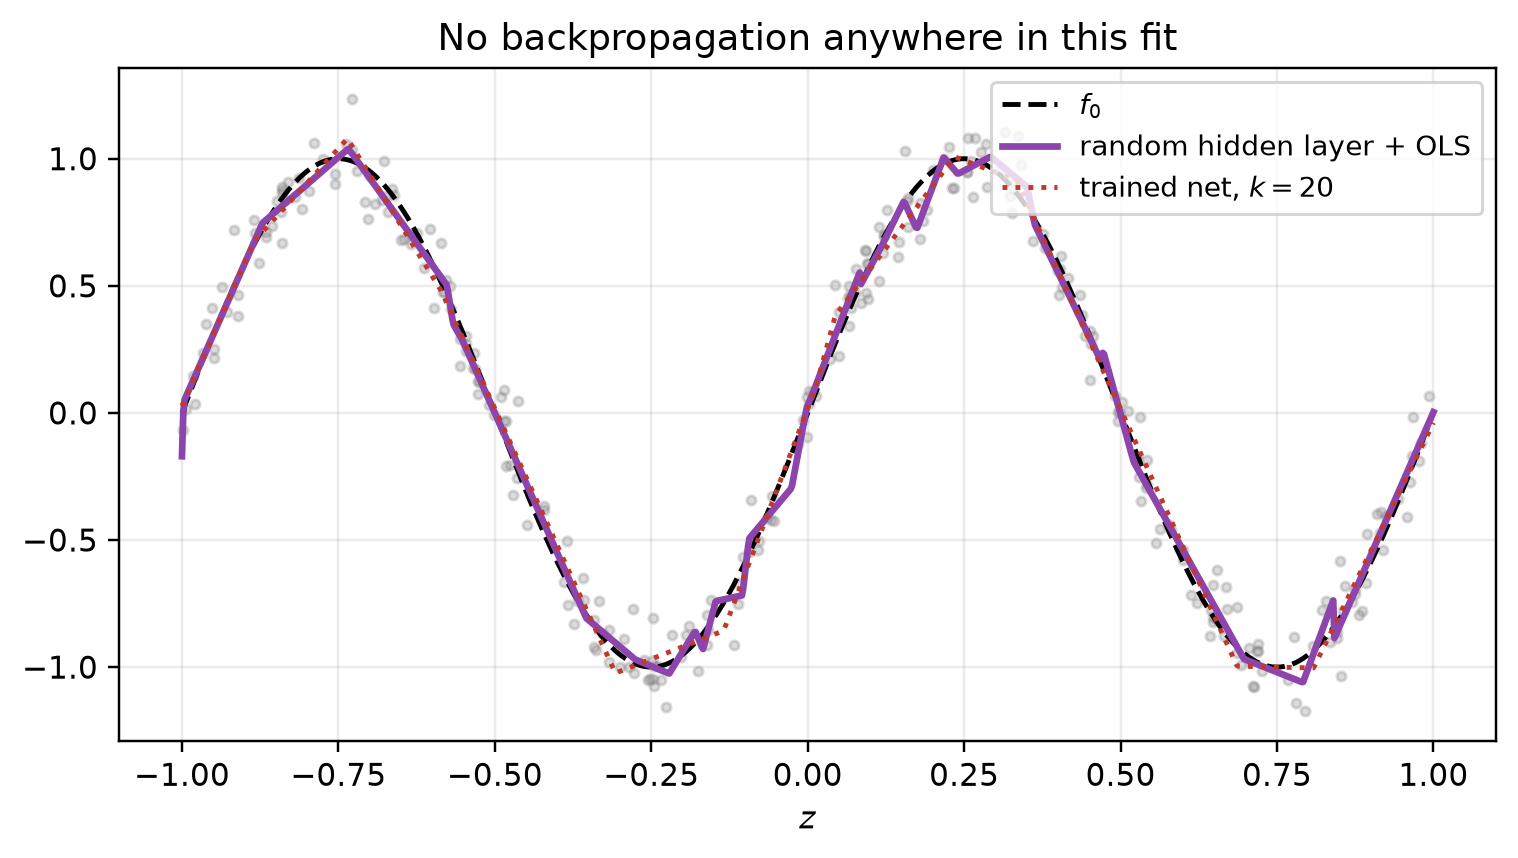

In [75]:
k_rf = 60
rs = np.random.default_rng(1)
w1_rf = rs.normal(0, 3, k_rf)      # random slopes  -> random kink orientations
w0_rf = rs.normal(0, 2, k_rf)      # random biases   -> random kink locations

A_tr = relu(w0_rf[None, :] + zz[:, None] * w1_rf[None, :])
X_tr = np.column_stack([np.ones(len(zz)), A_tr])
beta_hat, *_ = np.linalg.lstsq(X_tr, yy, rcond=None)      # plain OLS

A_g   = relu(w0_rf[None, :] + g[:, None] * w1_rf[None, :])
pred_rf = np.column_stack([np.ones(len(g)), A_g]) @ beta_hat

print(f"Random features + OLS  : train MSE {np.mean((X_tr@beta_hat - yy)**2):.5f}   "
      f"MSE vs truth {np.mean((pred_rf - truth)**2):.5f}")
print(f"Fully trained k=20 net : train MSE {np.mean((fits[20].predict(z_tr)-yy)**2):.5f}   "
      f"MSE vs truth {np.mean((fits[20].predict(grid)-truth)**2):.5f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(z_tr, y_tr, s=9, alpha=.28, color="gray")
ax.plot(g, truth, "k--", lw=1.6, label="$f_0$")
ax.plot(g, pred_rf, lw=2.2, color="#8e44ad", label="random hidden layer + OLS")
ax.plot(g, fits[20].predict(grid), lw=1.6, color="#c0392b", ls=":", label="trained net, $k=20$")
ax.legend(fontsize=9); ax.set_xlabel("$z$")
ax.set_title("No backpropagation anywhere in this fit")
plt.tight_layout(); plt.show()

On a one-dimensional problem, **random kinks plus OLS is competitive with a fully
trained network.** This is the *random features* idea (Rahimi & Recht 2008), and it is a
useful sanity anchor: a neural network is a linear model on a learned basis, and when
the input space is small a random basis is already pretty good. Training the basis pays
off when $p$ is large and the useful directions are rare — exactly the high-dimensional
regime this course cares about.

*(Random features are not on the slides. I include it because it is the cleanest possible
demonstration of the "convex in $\beta$, nonconvex in $\omega$" split, not because it is
examinable.)*


---
## Appendix D — Finance: learning an option-pricing surface

**Read this one.** It is the appendix most likely to matter in your own work: it is about
what happens when you want a *derivative* of the CEF rather than its level — a marginal
effect, an elasticity, a hedge ratio.

A European call under Black–Scholes has a closed-form price. Pricing one option is
instant; pricing millions inside a risk engine, or inside a calibration loop, is not. A
standard industry move is to train a network **once** as a fast surrogate for the pricing
function, then evaluate the network instead of the formula.

$$
C = S\,\Phi(d_1) - K e^{-rT}\Phi(d_2), \qquad
d_1 = \frac{\log(S/K) + (r + \tfrac12\sigma^2)T}{\sigma\sqrt{T}},\quad d_2 = d_1 - \sigma\sqrt{T}
$$

We train on $(S/K,\, T) \mapsto C$. This is a pure function-approximation problem — §4 in
two dimensions with no noise at all.

**But there is a second quantity that matters more than the price.** The hedge ratio is
$\Delta = \partial C/\partial S = \Phi(d_1)$. For an economist the analogue is obvious:
$\Delta$ is a **marginal effect**, and we care about marginal effects at least as much as
about levels. So we grade each network twice — on the function and on its derivative.

In [76]:
from scipy.stats import norm

def bs_call(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + .5 * sig**2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2), norm.cdf(d1)

rf = np.random.default_rng(7)
M = 12000
mny = rf.uniform(0.6, 1.4, M)      # moneyness S/K
mat = rf.uniform(0.05, 2.0, M)     # maturity in years
C_, D_ = bs_call(mny, 1.0, mat, r=0.02, sig=0.20)
Xo = np.column_stack([mny, mat])
Xtr_o, Xte_o, Ctr_o, Cte_o, Dtr_o, Dte_o = train_test_split(Xo, C_, D_, test_size=.3, random_state=0)

def numeric_delta(model, X, h=1e-3):
    """Finite-difference dC/d(moneyness) from the fitted network."""
    Xp, Xm = X.copy(), X.copy()
    Xp[:, 0] += h; Xm[:, 0] -= h
    return (model.predict(Xp) - model.predict(Xm)) / (2 * h)

nets = {}
print(f"{'activation':<12}{'price RMSE':>13}{'delta RMSE':>13}")
print("-" * 38)
for act in ["relu", "tanh"]:
    nets[act] = make_pipeline(StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 64), activation=act, alpha=1e-7,
                     max_iter=6000, random_state=0, tol=1e-10)).fit(Xtr_o, Ctr_o)
    pr = nets[act].predict(Xte_o)
    dn = numeric_delta(nets[act], Xte_o)
    print(f"{act:<12}{np.sqrt(np.mean((pr-Cte_o)**2)):>13.5f}{np.sqrt(np.mean((dn-Dte_o)**2)):>13.4f}")

activation     price RMSE   delta RMSE
--------------------------------------
relu              0.00119       0.0586
tanh              0.00352       0.0435


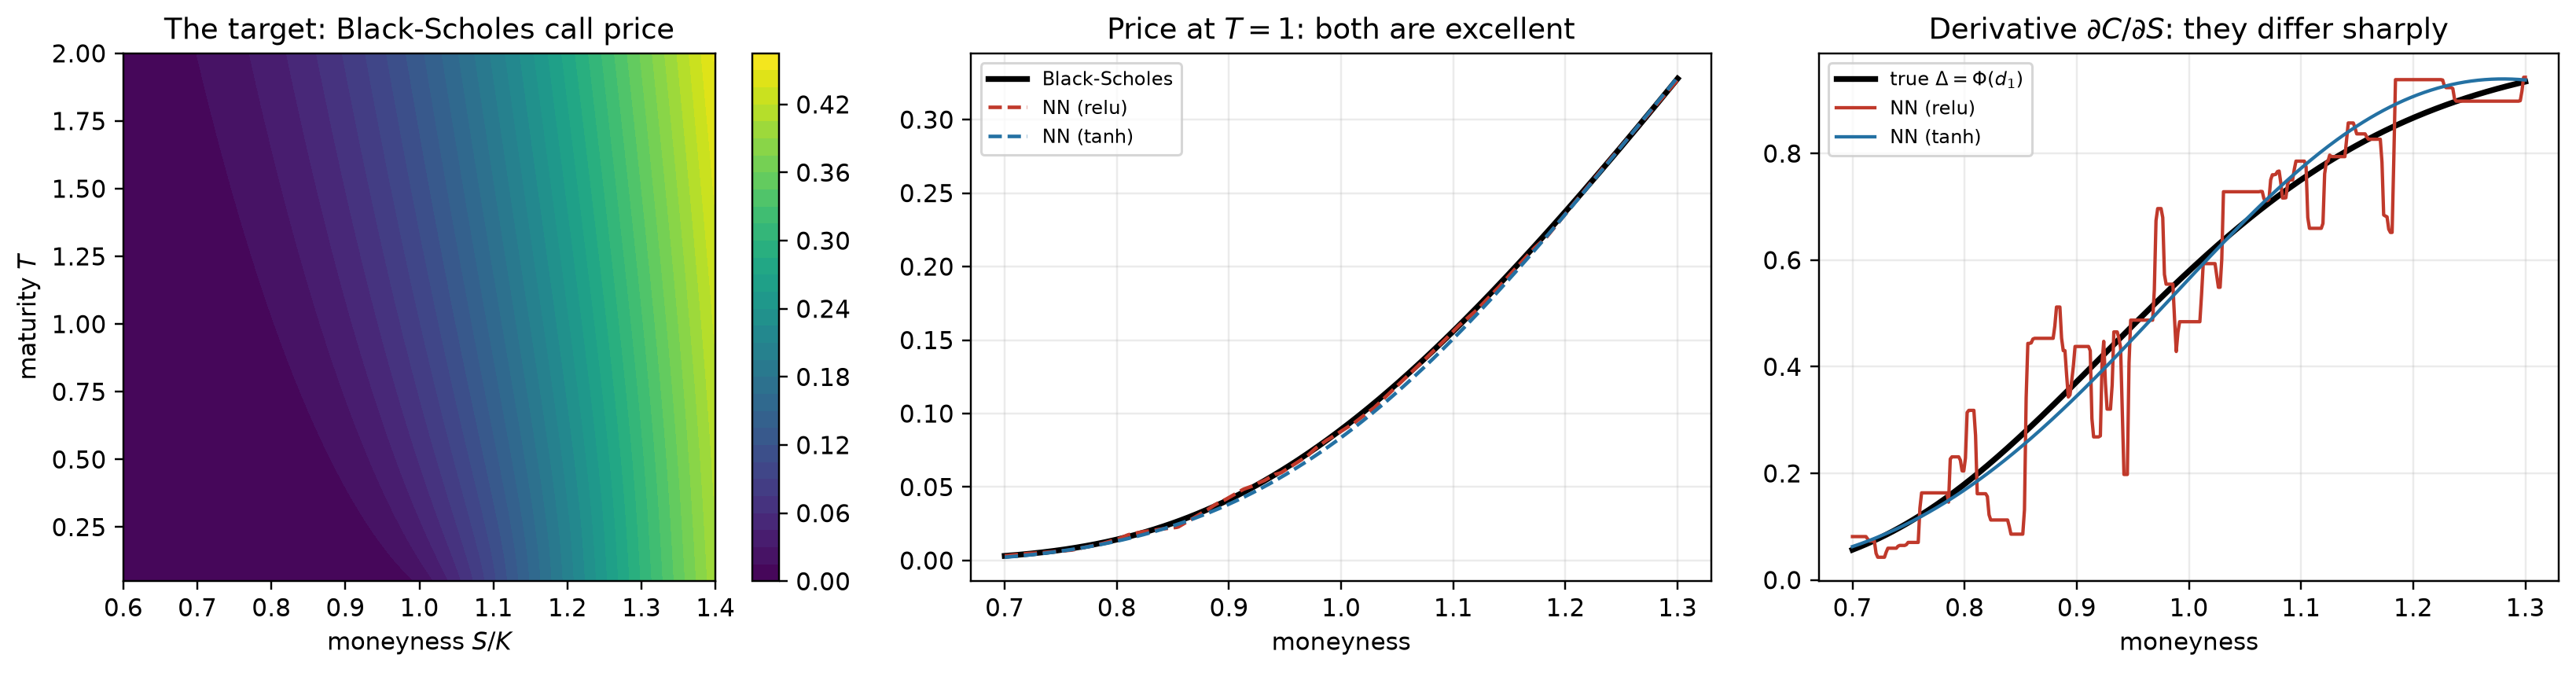

Roughness of the delta curve (total variation; lower = smoother)
  true Delta : 0.878
  NN relu  : 4.466
  NN tanh  : 0.879


In [77]:
sl = np.column_stack([np.linspace(.7, 1.3, 400), np.full(400, 1.0)])   # T = 1 year slice
C_sl, D_sl = bs_call(sl[:, 0], 1.0, sl[:, 1], 0.02, 0.20)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

gm, gT = np.meshgrid(np.linspace(.6, 1.4, 160), np.linspace(.05, 2.0, 160))
Cs, _ = bs_call(gm.ravel(), 1.0, gT.ravel(), 0.02, 0.20)
im = ax[0].contourf(gm, gT, Cs.reshape(gm.shape), 30, cmap="viridis")
plt.colorbar(im, ax=ax[0]); ax[0].set_xlabel("moneyness $S/K$"); ax[0].set_ylabel("maturity $T$")
ax[0].set_title("The target: Black-Scholes call price"); ax[0].grid(False)

ax[1].plot(sl[:, 0], C_sl, "k-", lw=2.4, label="Black-Scholes")
for act, c in [("relu", "#c0392b"), ("tanh", "#2471a3")]:
    ax[1].plot(sl[:, 0], nets[act].predict(sl), lw=1.5, ls="--", color=c, label=f"NN ({act})")
ax[1].set_title("Price at $T=1$: both are excellent"); ax[1].set_xlabel("moneyness")
ax[1].legend(fontsize=8)

ax[2].plot(sl[:, 0], D_sl, "k-", lw=2.4, label="true $\\Delta=\\Phi(d_1)$")
tv = {}
for act, c in [("relu", "#c0392b"), ("tanh", "#2471a3")]:
    dsl = numeric_delta(nets[act], sl)
    tv[act] = np.abs(np.diff(dsl)).sum()
    ax[2].plot(sl[:, 0], dsl, lw=1.4, color=c, label=f"NN ({act})")
ax[2].set_title("Derivative $\\partial C/\\partial S$: they differ sharply")
ax[2].set_xlabel("moneyness"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Roughness of the delta curve (total variation; lower = smoother)")
print(f"  true Delta : {np.abs(np.diff(D_sl)).sum():.3f}")
for act in ["relu", "tanh"]:
    print(f"  NN {act:<6}: {tv[act]:.3f}")

**The middle panel says the two networks are equally good. The right panel says they are
not.** The ReLU network's delta is a jagged staircase; the tanh network's delta traces the
true $\Phi(d_1)$ almost exactly.

The reason is §2 again, and it is not a numerical artefact. A ReLU network is **piecewise
linear**, so its derivative is **piecewise constant** — a step function, by construction. It
can approximate a smooth curve to any accuracy in *level* while its *derivative* keeps
jumping between the slopes of adjacent pieces. The total-variation numbers make this
quantitative: the true delta has roughness $0.878$ and the tanh network reproduces it at
$\approx 0.88$, while the ReLU network comes out around **five times too rough**.

> **The econometric lesson, and it generalizes well beyond option pricing.**
> ReLU wins on the level; tanh wins on the derivative. **Choose the activation to match
> the functional you care about.** Economists almost always want derivatives — marginal
> effects, elasticities, treatment-effect heterogeneity in a covariate. If your target is a
> derivative of the CEF, a ReLU network can be accurate and useless at the same time.
>
> *(This point is not on the slides; I include it because it is where deep learning most
> often bites applied economists, and it follows directly from the §2 geometry.)*


---
## Appendix E — Health: clinical risk prediction

Two datasets, two opposite conclusions. The point is to be honest about when a neural
network is the wrong tool — and this appendix pairs directly with Assignment 2.

Two datasets, two opposite conclusions. The point of this section is to be honest about
when a neural network is the wrong tool.

**Part A — real data.** The Wisconsin breast-cancer diagnostic dataset ships with
`scikit-learn`: 569 biopsies, 30 cell-nucleus measurements, benign vs. malignant.

In [78]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
Xh, yh = bc.data, bc.target
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=.3, random_state=0, stratify=yh)
print(f"{Xh.shape[0]} patients, {Xh.shape[1]} features, {yh.mean():.1%} benign\n")

logit_h = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xh_tr, yh_tr)
print(f"{'model':<30}{'train acc':>11}{'test acc':>10}{'test AUC':>10}")
print("-" * 61)
print(f"{'Logistic regression':<30}"
      f"{accuracy_score(yh_tr, logit_h.predict(Xh_tr)):>11.4f}"
      f"{accuracy_score(yh_te, logit_h.predict(Xh_te)):>10.4f}"
      f"{roc_auc_score(yh_te, logit_h.predict_proba(Xh_te)[:, 1]):>10.4f}")

for hl, al in [((4,), 1e-4), ((32,), 1e-4), ((128, 128), 1e-6), ((128, 128), 1.0)]:
    mh = make_pipeline(StandardScaler(),
         MLPClassifier(hidden_layer_sizes=hl, alpha=al, max_iter=4000,
                       random_state=0)).fit(Xh_tr, yh_tr)
    nm = f"MLP {hl}, alpha={al:g}"
    print(f"{nm:<30}"
          f"{accuracy_score(yh_tr, mh.predict(Xh_tr)):>11.4f}"
          f"{accuracy_score(yh_te, mh.predict(Xh_te)):>10.4f}"
          f"{roc_auc_score(yh_te, mh.predict_proba(Xh_te)[:, 1]):>10.4f}")

569 patients, 30 features, 62.7% benign

model                           train acc  test acc  test AUC
-------------------------------------------------------------
Logistic regression                0.9925    0.9591    0.9956
MLP (4,), alpha=0.0001             0.9925    0.9532    0.9928
MLP (32,), alpha=0.0001            0.9950    0.9532    0.9937
MLP (128, 128), alpha=1e-06        1.0000    0.9532    0.9921
MLP (128, 128), alpha=1            1.0000    0.9591    0.9950


Read the table carefully, because it contains the two things students most need to see.

1. **Logistic regression wins.** On this dataset the decision boundary is close to linear
   in the standardized features, so the extra flexibility buys nothing. A neural network
   is not a free upgrade.
2. **Look at the `(128, 128), alpha=1e-6` row.** Training accuracy is exactly $1.0000$ —
   perfect memorization of 398 patients using tens of thousands of parameters — while
   test accuracy *drops*. That is overfitting in its purest form, and it is the practical
   meaning of "modern architectures are often highly overparametrized" on slide 51.
   Raising `alpha` to $1.0$ (the $\mathrm{pen}_\lambda(\theta)$ term) pulls test performance
   back up. **The penalty is not decoration.**

**Part B — when the network does win.** Clinical risk often has threshold-and-interaction
structure: a biomarker is dangerous *only* above a cutoff, and *only* in older patients.
We simulate exactly that:

$$
P(\text{event}) = \Lambda\big(-3 + 2.5\cdot\mathbf{1}\{\text{age}>55\}\cdot\mathbf{1}\{\text{biomarker}>6\} + 0.02\,\text{age} + 0.05\,\text{biomarker}\big)
$$


In [79]:
rh = np.random.default_rng(11)
nh = 4000
age = rh.uniform(20, 80, nh)
bio = rh.uniform(0, 10, nh)
risk = 1 / (1 + np.exp(-(-3 + 2.5 * ((age > 55) & (bio > 6)).astype(float)
                         + 0.02 * age + 0.05 * bio)))
event = rh.binomial(1, risk)
Xr = np.column_stack([age, bio])
Xr_tr, Xr_te, yr_tr, yr_te, rr_tr, rr_te = train_test_split(
    Xr, event, risk, test_size=.3, random_state=0)

logit_r = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(Xr_tr, yr_tr)
mlp_r   = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32, 32),
                        alpha=1e-3, max_iter=4000, random_state=0)).fit(Xr_tr, yr_tr)

print(f"{'model':<22}{'AUC':>8}{'MSE vs TRUE risk':>20}")
print("-" * 50)
for nm, md in [("Logistic regression", logit_r), ("MLP (32, 32)", mlp_r)]:
    pr = md.predict_proba(Xr_te)[:, 1]
    print(f"{nm:<22}{roc_auc_score(yr_te, pr):>8.4f}{np.mean((pr - rr_te)**2):>20.5f}")
print(f"{'TRUE risk (ceiling)':<22}{roc_auc_score(yr_te, rr_te):>8.4f}{0.0:>20.5f}")

model                      AUC    MSE vs TRUE risk
--------------------------------------------------
Logistic regression     0.7538             0.01823
MLP (32, 32)            0.7480             0.00377
TRUE risk (ceiling)     0.7663             0.00000


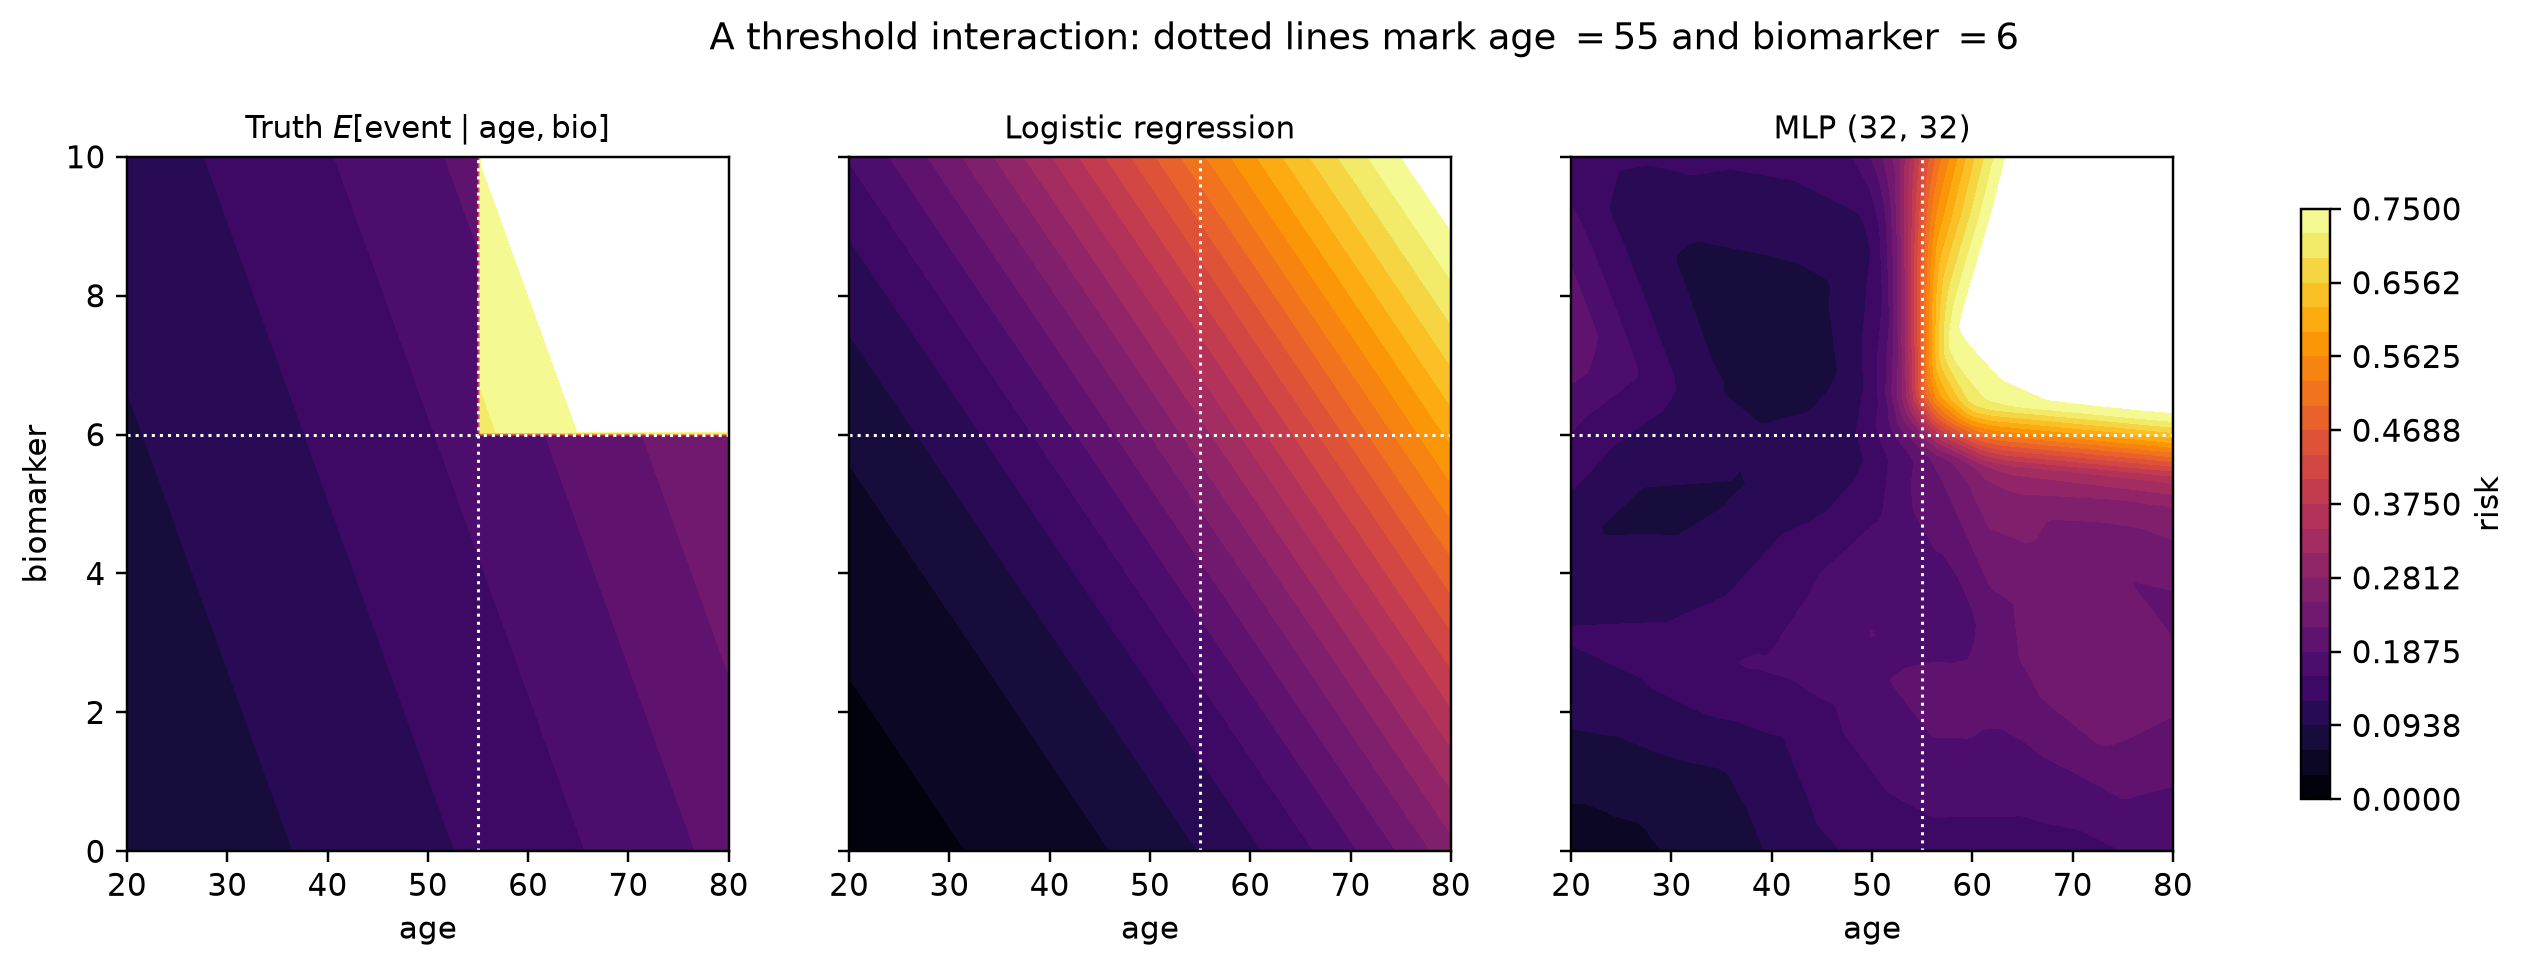

In [80]:
ga_, gb_ = np.meshgrid(np.linspace(20, 80, 200), np.linspace(0, 10, 200))
Gr = np.column_stack([ga_.ravel(), gb_.ravel()])
R_true = (1 / (1 + np.exp(-(-3 + 2.5 * ((ga_ > 55) & (gb_ > 6)).astype(float)
                            + 0.02 * ga_ + 0.05 * gb_))))

panels = [("Truth $E[\\mathrm{event}\\mid \\mathrm{age},\\mathrm{bio}]$", R_true),
          ("Logistic regression", logit_r.predict_proba(Gr)[:, 1].reshape(ga_.shape)),
          ("MLP (32, 32)",        mlp_r.predict_proba(Gr)[:, 1].reshape(ga_.shape))]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.1), sharey=True)
for a_, (nm, S) in zip(ax, panels):
    im = a_.contourf(ga_, gb_, S, levels=np.linspace(0, .75, 25), cmap="inferno")
    a_.axvline(55, color="w", ls=":", lw=1); a_.axhline(6, color="w", ls=":", lw=1)
    a_.set_title(nm, fontsize=10); a_.set_xlabel("age"); a_.grid(False)
ax[0].set_ylabel("biomarker")
fig.colorbar(im, ax=ax, shrink=.85, label="risk")
plt.suptitle("A threshold interaction: dotted lines mark age $=55$ and biomarker $=6$",
             y=1.03, fontsize=12)
plt.show()

The truth is a flat plane with one raised rectangle in the top-right corner. Logistic
regression, being a monotone function of a linear index, smears a diagonal gradient
across the whole space — it cannot put a box anywhere. The MLP finds the box.

Now notice something subtle in the table, because it is a trap worth naming:

- On **AUC** the two models are nearly tied.
- On **MSE against the true risk function** the MLP is roughly **five times better**.

AUC only measures *ranking* — whether higher-risk patients get higher scores. Both models
rank acceptably, since risk still increases with age and biomarker overall. But this
course is about estimating $E[Y\mid Z]$, and for *that* the logistic model is badly
miscalibrated in the corner where the action is. **Choose the metric that matches the
estimand.** If you only ever look at AUC, you will conclude the two models are equivalent
and you will be wrong about the thing you actually wanted.

> **Summary of Appendix E.** Reach for a network when you suspect thresholds, interactions, or
> structure you cannot write down. Do not reach for one because it is fashionable: on
> near-linear problems it costs you interpretability, stability, and standard errors, and
> gives nothing back.


---
# 10. Wrap-up

### The five things to remember

1. **A neural network is a linear regression on a basis it learns from the data.**
   Series regression fixes the basis and estimates coefficients; a network estimates
   both. Everything else follows from that one difference.
2. **Each ReLU neuron contributes one kink**, at $z = -\omega_{j0}/\omega_{j1}$, with slope
   $\omega_{j1}$. $k$ neurons give a piecewise-linear function with $k$ freely placed knots —
   which is why the universal approximation theorem is almost obvious for ReLU.
3. **Width adds kinks; depth multiplies them.** $2L$ neurons arranged in depth produce
   $2^{L-1}$ oscillations. But that is a statement about *representation*: we saw that
   training may not find it.
4. **The nonconvexity lives in the hidden layers.** Fix them and you are doing OLS. This
   is why 30 random starts gave 18 different local optima, and why reporting a single
   unseeded fit is not defensible.
5. **Match the tool to the estimand.** ReLU for levels, smooth activations for marginal
   effects; MSE against the CEF rather than AUC when you want $E[Y\mid Z]$; and a linear
   model when the problem is linear.

### What comes next in the lecture

We stopped at *Training NNs: Basic Idea*. The remaining slides answer the question this
notebook left open — **which direction should $\theta$ move?** — with gradient descent,
backpropagation and stochastic gradient descent, plus dropout as regularization.

### Exercises

1. **Kink budget.** Fit shallow ReLU networks with $k = 2, 4, 8, 16$ to
   $f_0(z) = \sin(4\pi z)$ on $[-1,1]$. That target has twice the oscillation of §4. How
   many neurons do you need before the fit is visually acceptable, and how does that
   compare with the kink-counting argument?
2. **Activation and derivatives.** Redo **Appendix D** with `activation="logistic"`. Where does it
   land relative to ReLU and tanh on price RMSE and on delta RMSE? Explain using the
   derivative plots from §2.
3. **The cost of a single fit.** Take the §6 xG network and refit it with
   `random_state` $= 0, \dots, 19$. Report the spread of test AUC. How large is the gap
   between the luckiest and unluckiest seed, and what would you report in a paper?
4. **Regularization path.** On the breast-cancer data, trace train and test accuracy for
   a $(128,128)$ network as `alpha` sweeps $10^{-6}$ to $10^{2}$. Where is the sweet spot,
   and how does the shape compare with the LASSO path from Lab 1?
5. **Depth, honestly.** Verify the claim in **Appendix B** that a shallow network needs roughly one
   neuron per kink: fit networks with $k = 8, 16, 32, 64$ to the 8-tooth sawtooth and find
   where the MSE collapses. Does the threshold match the prediction?

### References

Cybenko, G. (1989): "Approximation by superpositions of a sigmoidal function,"
*Mathematics of Control, Signals and Systems*, 2, 303–314.

Hanin, B. and M. Sellke (2017): "Approximating continuous functions by ReLU nets of
minimal width," arXiv:1710.11278.

Hornik, K., M. Stinchcombe and H. White (1989): "Multilayer feedforward networks are
universal approximators," *Neural Networks*, 2, 359–366.

Kidger, P. and T. Lyons (2020): "Universal approximation with deep narrow networks,"
*Conference on Learning Theory*, 2306–2327.

Leshno, M., V. Lin, A. Pinkus and S. Schocken (1993): "Multilayer feedforward networks
with a nonpolynomial activation function can approximate any function," *Neural
Networks*, 6, 861–867.

McCulloch, W. and W. Pitts (1943): "A logical calculus of the ideas immanent in nervous
activity," *Bulletin of Mathematical Biophysics*, 5, 115–133.

Pinkus, A. (1999): "Approximation theory of the MLP model in neural networks," *Acta
Numerica*, 8, 143–195.

Rosenblatt, F. (1958): "The perceptron: A probabilistic model for information storage and
organization in the brain," *Psychological Review*, 65, 386–408.

Stone, C. J. (1982): "Optimal global rates of convergence for nonparametric regression,"
*The Annals of Statistics*, 10, 1040–1053.

Yarotsky, D. and A. Zhevnerchuk (2020): "The phase diagram of approximation rates for
deep neural networks," *Advances in Neural Information Processing Systems*, 33,
13005–13015.

*Two items used above are outside the lecture's reference list and are flagged as such in
the text: the random-features idea (Rahimi & Recht 2008) in §6, and the depth-separation
sawtooth construction, which is standard in the expressivity literature (see Telgarsky
2016 for the canonical version).*
